# Multi-Modal Video RAG Pipeline Architecture

## System Overview

This pipeline implements an end-to-end Multi-Modal Retrieval-Augmented Generation (RAG) system designed to ingest, process, index, and query unstructured video content (specifically tailored for cooking and instructional media). 

* **Multi-Modal Data Ingestion & Extraction:**
  * Extracts structural keyframe shots using PySceneDetect adaptive boundary detection.
  * Captures auditory signals by extracting transcripts with Sarvam AI (`saaras:v3`) bilingual ASR (Bengali and English).
  * Obtains visual signals via YOLOv8 object/utensil detection, EasyOCR with CLAHE preprocessing, and Qwen2-VL-2B-Instruct keyframe action/scene captioning.

* **Structured Knowledge Modeling:**
  * Uses Qwen2.5-1.5B-Instruct to compile noisy multi-modal extractions into grounded, schema-validated JSON metadata.
  * Builds a directed NetworkX Knowledge Graph (`video_rag_kg.graphml`) connecting Dishes, Cuisines, Ingredients, Cooking Steps, and Visual Utensils.

* **Hybrid Retrieval Mechanics:**
  * **Dense Vector Channel:** Executes semantic similarity search over text chunks using FAISS and `all-MiniLM-L6-v2` embeddings.
  * **Sparse Lexical Channel:** Performs exact term matching via BM25Okapi over transcripts, ingredients, steps, and OCR logs.
  * **Graph Traversal Channel:** Performs 1-hop and 2-hop relational context expansion across entity nodes.

* **Context Fusion & Non-Hallucinated Generation:**
  * Fuses retrieved contexts into explicit semantic, keyword, and structural graph blocks.
  * Prompts Qwen2.5-1.5B-Instruct to deliver deterministic, fully grounded, non-hallucinated responses through an interactive interface.

In [1]:
!pip install -q --no-warn-conflicts \
    scenedetect \
    ultralytics \
    easyocr \
    transformers \
    accelerate \
    qwen-vl-utils \
    "pillow<12.0" \
    opencv-python-headless \
    faiss-gpu \
    sentence-transformers \
    requests \
    networkx \
    matplotlib \
    rank-bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 13.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 59.8 MB/s eta 0:00:00:00:0100:01


### Step 1: Pre-Processing, Audio Transcription & Shot Segmentation

* **Environment & Warnings Configuration:**
  * Configures global `warnings` filters to suppress harmless Python 3.12 syntax warnings (`invalid escape sequence`) originating from third-party multimedia libraries like `MoviePy`.
* **Audio Extraction & Speech-to-Text (STT):**
  * Extracts raw 16kHz mono audio (`pcm_s16le`) from input videos via `FFmpeg`.
  * Processes audio in 25-second chunks using the **Sarvam AI (`saaras:v3`) STT API** to transcribe Bengali spoken audio (`bn-IN`) with word-level timestamps.
  * Translates chunked Bengali transcripts into formal English using the **Sarvam AI Translation API** (`bn-IN` -> `en-IN`).
* **Keyframe & Shot Boundary Detection:**
  * Uses `PySceneDetect` (`AdaptiveDetector`) to dynamically identify shot boundaries and save midpoint keyframes (`.jpg`).
  * Implements a fallback sampling mechanism every 4 seconds when fewer than 8 scene transitions are detected to guarantee complete visual coverage.
* **Spatial Object Detection & Annotation:**
  * Runs **YOLOv8** (`yolov8n`) on extracted keyframes via CUDA/CPU to identify utensils, ingredients, and bounding box coordinates (`xyxy`).
  * Structured metadata (video attributes, STT transcripts, shot boundaries, and object detections) is compiled and exported as JSON files into `/kaggle/working/Video-RAG/Metadata`.

In [2]:
import warnings

# Suppress Python 3.12 invalid escape sequence warnings from external libraries
warnings.filterwarnings("ignore", category=SyntaxWarning)

import os
import glob
import json
import cv2
import torch
import requests
import subprocess
import math
from getpass import getpass
from scenedetect import detect, AdaptiveDetector
from ultralytics import YOLO

# 1. Sarvam API & Path Configuration

# Step A: Attempt to retrieve the API key automatically
SARVAM_API_KEY = None

try:
    from kaggle_secrets import UserSecretsClient
    SARVAM_API_KEY = UserSecretsClient().get_secret("SARVAM_API_KEY")
except Exception:
    SARVAM_API_KEY = os.environ.get("SARVAM_API_KEY")

# Step B: Check and prompt if missing
if SARVAM_API_KEY:
    print("[INFO] Sarvam API key found! Proceeding with execution...")
else:
    print("[INFO] Sarvam API key not found in Kaggle Secrets or environment.")
    SARVAM_API_KEY = getpass("Please enter your Sarvam API key: ").strip()
    
    # Store key in environment for the session
    if SARVAM_API_KEY:
        os.environ["SARVAM_API_KEY"] = SARVAM_API_KEY
        print("[SUCCESS] Sarvam API key loaded successfully! Proceeding...")
    else:
        raise ValueError("[ERROR] Sarvam API key is required to run the pipeline.")

INPUT_SEARCH_DIR = "/kaggle/input"
OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
KEYFRAMES_DIR = os.path.join(OUTPUT_DIR, "Keyframes")
AUDIO_DIR = os.path.join(OUTPUT_DIR, "Audio")

os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(KEYFRAMES_DIR, exist_ok=True)
os.makedirs(AUDIO_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Running Step 1 on device: {device}")

video_extensions = ("*.mp4", "*.mov", "*.mkv", "*.avi")
video_files = []
for ext in video_extensions:
    video_files.extend(glob.glob(os.path.join(INPUT_SEARCH_DIR, "**", ext), recursive=True))

if not video_files:
    raise FileNotFoundError(f"No video files found under '{INPUT_SEARCH_DIR}'.")

print(f"[INFO] Found {len(video_files)} video file(s) for processing.")

# Load YOLOv8 model for object detection
print("[1/1] Loading YOLOv8 model...")
yolo_model = YOLO("yolov8n.pt").to(device)


# 2. Helper Functions for Audio Processing & Sarvam STT/Translation
def extract_audio(video_path, audio_path):
    cmd = [
        "ffmpeg", "-y", "-i", video_path, 
        "-vn", "-acodec", "pcm_s16le", "-ar", "16000", "-ac", "1", 
        audio_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def get_audio_duration(audio_path):
    cmd = [
        "ffprobe", "-v", "error", "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1", audio_path
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    try:
        return float(result.stdout)
    except ValueError:
        return 0.0

def process_audio_in_chunks_sarvam(audio_path, chunk_sec=25):
    duration = get_audio_duration(audio_path)
    if duration == 0:
        return "", "", []
    
    num_chunks = math.ceil(duration / chunk_sec)
    full_bn_transcript = []
    full_en_transcript = []
    all_timestamps = []
    
    url_stt = "https://api.sarvam.ai/speech-to-text"
    url_trans = "https://api.sarvam.ai/translate"
    headers = {"api-subscription-key": SARVAM_API_KEY}
    
    for i in range(num_chunks):
        start_t = i * chunk_sec
        chunk_file = audio_path.replace(".wav", f"_chunk_{i}.wav")
        
        cmd = [
            "ffmpeg", "-y", "-ss", str(start_t), "-i", audio_path,
            "-t", str(chunk_sec), "-c", "copy", chunk_file
        ]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
        payload_stt = {
            "language_code": "bn-IN",
            "model": "saaras:v3",
            "with_timestamps": "true"
        }
        
        chunk_bn_text = ""
        try:
            with open(chunk_file, "rb") as f:
                files = [("file", (os.path.basename(chunk_file), f, "audio/wav"))]
                resp = requests.post(url_stt, headers=headers, data=payload_stt, files=files)
                if resp.status_code == 200:
                    res_data = resp.json()
                    chunk_bn_text = res_data.get("transcript", "").strip() if isinstance(res_data, dict) else ""
                    
                    timestamps_raw = res_data.get("timestamps", []) if isinstance(res_data, dict) else []
                    if isinstance(timestamps_raw, list):
                        for seg in timestamps_raw:
                            if isinstance(seg, dict):
                                all_timestamps.append({
                                    "start": round(start_t + seg.get("start_time_seconds", 0.0), 2),
                                    "end": round(start_t + seg.get("end_time_seconds", 0.0), 2),
                                    "text": seg.get("message", "").strip()
                                })
                else:
                    print(f"[WARNING] Chunk {i+1} Sarvam STT error ({resp.status_code}): {resp.text}")
        except Exception as e:
            print(f"[ERROR] Chunk {i+1} exception: {e}")
            
        if chunk_bn_text:
            full_bn_transcript.append(chunk_bn_text)
            
            headers_trans = {
                "api-subscription-key": SARVAM_API_KEY,
                "Content-Type": "application/json"
            }
            payload_trans = {
                "input": chunk_bn_text,
                "source_language_code": "bn-IN",
                "target_language_code": "en-IN",
                "mode": "formal"
            }
            try:
                t_resp = requests.post(url_trans, headers=headers_trans, json=payload_trans)
                if t_resp.status_code == 200:
                    chunk_en_text = t_resp.json().get("translated_text", "").strip()
                    if chunk_en_text:
                        full_en_transcript.append(chunk_en_text)
            except Exception as e:
                print(f"[WARNING] Chunk {i+1} translation exception: {e}")
                
        if os.path.exists(chunk_file):
            os.remove(chunk_file)
            
        print(f"  --> Chunk [{i + 1}/{num_chunks}] processing completed.")

    final_bn = " ".join(full_bn_transcript).strip()
    final_en = " ".join(full_en_transcript).strip()
    return final_bn, final_en, all_timestamps


# 3. Pipeline Execution
for idx, video_path in enumerate(video_files, start=1):
    video_filename = os.path.basename(video_path)
    video_id, _ = os.path.splitext(video_filename)
    output_json_path = os.path.join(METADATA_DIR, f"{video_id}_metadata.json")
    
    print(f"\n[INFO] Processing [{idx}/{len(video_files)}]: {video_filename}")

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = round(total_frames / fps, 2) if fps > 0 else 0
    file_size_mb = f"{round(os.path.getsize(video_path) / (1024 * 1024), 2)} MB"

    print("Extracting audio and processing chunks via Sarvam AI...")
    audio_path = os.path.join(AUDIO_DIR, f"{video_id}.wav")
    extract_audio(video_path, audio_path)
    
    transcript_bn, transcript_en, timestamps = process_audio_in_chunks_sarvam(audio_path)
    print(f"[STT RESULT] Bengali Transcript Length: {len(transcript_bn)} chars")
    print(f"[STT RESULT] English Transcript Length: {len(transcript_en)} chars")

    print("Performing keyframe extraction...")
    try:
        scene_list = detect(video_path, AdaptiveDetector())
    except Exception:
        scene_list = []

    # Sample keyframes every 4 seconds if PySceneDetect detects fewer than 8 scenes
    if len(scene_list) < 8:
        print("[INFO] Sparse scene transitions detected. Sampling keyframes every 4 seconds for full caption coverage...")
        interval = 4.0
        shots_data = []
        curr = 0.0
        while curr < duration:
            end_t = min(curr + interval, duration)
            shots_data.append((curr, end_t))
            curr += interval
    else:
        shots_data = [(s[0].get_seconds(), s[1].get_seconds()) for s in scene_list]

    shots = []
    frames_info = []

    video_keyframes_dir = os.path.join(KEYFRAMES_DIR, video_id)
    os.makedirs(video_keyframes_dir, exist_ok=True)

    for s_idx, (start_t, end_t) in enumerate(shots_data, start=1):
        shot_id = f"shot_{s_idx:02d}"
        mid_t = (start_t + end_t) / 2.0
        
        target_frame = int(mid_t * fps)
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        
        frame_path = ""
        if ret:
            frame_path = os.path.join(video_keyframes_dir, f"{shot_id}.jpg")
            cv2.imwrite(frame_path, frame)
        
        shots.append({
            "shot_id": shot_id,
            "start_time": round(start_t, 2),
            "end_time": round(end_t, 2),
            "duration": round(end_t - start_t, 2),
            "keyframe_path": frame_path
        })
        
        frames_info.append({
            "frame_id": f"{video_id}_{shot_id}_f1",
            "shot_id": shot_id,
            "timestamp": round(mid_t, 2),
            "frame_path": frame_path
        })

    cap.release()

    print("Running YOLOv8 object detection...")
    object_detections = []
    visual_descriptions = []

    for frame in frames_info:
        f_path = frame["frame_path"]
        f_id = frame["frame_id"]
        shot_id = frame["shot_id"]
        
        if os.path.exists(f_path):
            results = yolo_model(f_path, verbose=False)[0]
            detected_objects = []
            
            for box in results.boxes:
                class_id = int(box.cls[0])
                label = results.names[class_id]
                confidence = round(float(box.conf[0]), 2)
                detected_objects.append({
                    "class_name": label,
                    "confidence": confidence,
                    "bbox": [round(x, 2) for x in box.xyxy[0].tolist()]
                })
            
            object_detections.append({
                "frame_id": f_id,
                "shot_id": shot_id,
                "detected_objects": detected_objects
            })
            
            unique_labels = sorted(list({obj["class_name"] for obj in detected_objects}))
            desc = f"Keyframe contains: {', '.join(unique_labels)}." if unique_labels else "Keyframe depicts cooking process scene."
                
            visual_descriptions.append({
                "frame_id": f_id,
                "shot_id": shot_id,
                "description": desc
            })

    team_json = {
        "video_info": {
            "video_id": video_id,
            "video_name": video_filename,
            "title": video_id.replace("_", " ").title(),
            "category": "Cooking",
            "language": "bn",
            "duration": duration,
            "fps": round(fps, 2),
            "width": width,
            "height": height,
            "total_frames": total_frames,
            "file_size": file_size_mb,
            "video_path": video_path
        },
        "recipe_information": {
            "dish_type": "",
            "ingredients": [],
            "estimated_steps": [],
            "cuisine": "Bengali",
            "tags": []
        },
        "audio_information": {
            "transcript_bn": transcript_bn,
            "transcript_en": transcript_en,
            "timestamps": timestamps
        },
        "shot_information": shots,
        "frame_information": frames_info,
        "object_detection": object_detections,
        "visual_descriptions": visual_descriptions
    }

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(team_json, f, indent=2, ensure_ascii=False)

    print(f"[INFO] Metadata saved to: {output_json_path}")

print("\n[INFO] Step 1 complete.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] Sarvam API key not found in Kaggle Secrets or environment.


Please enter your Sarvam API key:  ········


[SUCCESS] Sarvam API key loaded successfully! Proceeding...
[INFO] Running Step 1 on device: cuda:0
[INFO] Found 5 video file(s) for processing.
[1/1] Loading YOLOv8 model...

[INFO] Processing [1/5]: Coconut Rice.mp4
Extracting audio and processing chunks via Sarvam AI...
  --> Chunk [1/3] processing completed.
  --> Chunk [2/3] processing completed.
  --> Chunk [3/3] processing completed.
[STT RESULT] Bengali Transcript Length: 1237 chars
[STT RESULT] English Transcript Length: 1521 chars
Performing keyframe extraction...
Running YOLOv8 object detection...
[INFO] Metadata saved to: /kaggle/working/Video-RAG/Metadata/Coconut Rice_metadata.json

[INFO] Processing [2/5]: Yogurt Chicken.mp4
Extracting audio and processing chunks via Sarvam AI...
  --> Chunk [1/6] processing completed.
  --> Chunk [2/6] processing completed.
  --> Chunk [3/6] processing completed.
  --> Chunk [4/6] processing completed.
  --> Chunk [5/6] processing completed.
  --> Chunk [6/6] processing completed.
[STT R

### Step 2: Multi-Modal Context Extraction & Structured Schema Generation

* **Optical Character Recognition (OCR) & Text Sanitization:**
  * Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) pre-processing to boost keyframe image contrast for video subtitles.
  * Employs bilingual EasyOCR (`bn`, `en`) across both raw and enhanced frames to extract embedded on-screen text and subtitles.
  * Implements regex-based noise filtering, script validation (English and Bengali script), and consecutive word deduplication to purge OCR artifacts.
* **Vision-Language Model (VLM) Keyframe Captioning:**
  * Uses **Qwen2-VL-2B-Instruct** in half-precision (`fp16`) with bounded image resolution scaling (`min_pixels=128*28*28`, `max_pixels=256*28*28`).
  * Generates concise, 1-sentence action, utensil, and ingredient descriptions for every extracted keyframe and appends them to the frame metadata.
* **Structured Recipe Parsing & Dynamic Ground Truth Verification:**
  * Deploys **Qwen2.5-1.5B-Instruct** with chat templates and forced JSON prefixing (`{\n`) to extract canonical recipe components (`dish_type`, `ingredients`, `estimated_steps`, `tips`, `cuisine`, `tags`).
  * Scans for matching ground-truth `.txt` files in `/kaggle/input`; if available, fuses ground-truth text with audio transcripts, OCR, and VLM captions for verified parsing; otherwise, extracts purely from multimodal context.
* **GPU Memory Management:**
  * Enforces garbage collection (`gc.collect()`), CUDA cache clearing (`torch.cuda.empty_cache()`), and explicit model unloading between all execution phases to run within GPU VRAM limits.

In [42]:
import os
import glob
import json
import gc
import re
import warnings
import cv2
import torch
import easyocr
from PIL import Image

try:
    from kaggle_secrets import UserSecretsClient
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    os.environ["HF_HUB_VERBOSITY"] = "error"

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
warnings.filterwarnings("ignore")

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, AutoModelForCausalLM, AutoTokenizer

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def preprocess_image_for_ocr(img_path):
    # Enhance image contrast for video subtitles
    img = cv2.imread(img_path)
    if img is None:
        return img_path
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    temp_path = img_path.replace(".jpg", "_ocr_prep.jpg")
    cv2.imwrite(temp_path, enhanced)
    return temp_path

def clean_ocr_text(text):
    # Filter out noise, repeated fragments, and garbage characters
    if not text or len(text.strip()) < 3:
        return ""
    
    # Retain standard English, Bengali script, numbers, and common punctuation
    cleaned = re.sub(r'[^a-zA-Z0-9\u0980-\u09FF\s,.]', ' ', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    # Drop short alphanumeric junk
    if len(cleaned) < 3 and not re.search(r'[\u0980-\u09FF]', cleaned):
        return ""
    
    # Deduplicate repeated adjacent words
    words = cleaned.split()
    deduped = []
    for w in words:
        if not deduped or deduped[-1].lower() != w.lower():
            deduped.append(w)
            
    return " ".join(deduped)

INPUT_SEARCH_DIR = "/kaggle/input"
OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))

device = "cuda" if torch.cuda.is_available() else "cpu"

# Phase 1: EasyOCR with cleaning

print("\n[PHASE 1/3] Running EasyOCR with Garbage/Noise Filtering...")
ocr_reader = easyocr.Reader(['bn', 'en'], gpu=torch.cuda.is_available())

for meta_file in metadata_files:
    with open(meta_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for frame in data.get("frame_information", []):
        f_path = frame.get("frame_path", "")
        if os.path.exists(f_path):
            try:
                prep_path = preprocess_image_for_ocr(f_path)
                
                results_enhanced = ocr_reader.readtext(prep_path, detail=0, paragraph=True)
                results_orig = ocr_reader.readtext(f_path, detail=0, paragraph=True)
                
                all_results = results_enhanced + results_orig
                
                # Filter noise
                cleaned_list = []
                for t in all_results:
                    c = clean_ocr_text(t)
                    if c and c not in cleaned_list:
                        cleaned_list.append(c)
                
                frame["ocr_text"] = " | ".join(cleaned_list).strip()
                
                if os.path.exists(prep_path):
                    os.remove(prep_path)
            except Exception as e:
                print(f"[WARNING] OCR exception on {f_path}: {e}")
                frame["ocr_text"] = ""

    with open(meta_file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

del ocr_reader
clear_vram()

# Phase 2: Qwen2-VL captioning

print("\n[PHASE 2/3] Loading Qwen2-VL...")
vlm_model_id = "Qwen/Qwen2-VL-2B-Instruct"

vlm_processor = AutoProcessor.from_pretrained(
    vlm_model_id, min_pixels=128*28*28, max_pixels=256*28*28, use_fast=True
)
vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    vlm_model_id, dtype=torch.float16, device_map="auto"
)

for meta_file in metadata_files:
    with open(meta_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for frame in data.get("frame_information", []):
        f_path = frame.get("frame_path", "")
        f_id = frame.get("frame_id", "")
        
        if os.path.exists(f_path):
            image = Image.open(f_path).convert("RGB")
            prompt = (
                "<|im_start|>system\nYou are a cooking visual assistant.<|im_end|>\n"
                "<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>"
                "Describe the cooking action, ingredients, or utensil in 1 short sentence.<|im_end|>\n"
                "<|im_start|>assistant\n"
            )
            inputs = vlm_processor(text=[prompt], images=[image], return_tensors="pt").to(device)
            
            with torch.no_grad():
                output_ids = vlm_model.generate(**inputs, max_new_tokens=40, do_sample=False)
            
            trimmed_ids = output_ids[0][inputs.input_ids.shape[1]:]
            caption = vlm_processor.decode(trimmed_ids, skip_special_tokens=True).strip()
            
            for v_desc in data.get("visual_descriptions", []):
                if v_desc.get("frame_id") == f_id:
                    v_desc["description"] = caption
                    v_desc["ocr_text"] = frame.get("ocr_text", "")

    with open(meta_file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

del vlm_model
del vlm_processor
clear_vram()

# Phase 3: Dynamic recipe extraction (TXT & JSON Support)

print("\n[PHASE 3/3] Parsing Recipe Details...")
text_llm_id = "Qwen/Qwen2.5-1.5B-Instruct"
text_tokenizer = AutoTokenizer.from_pretrained(text_llm_id)
text_model = AutoModelForCausalLM.from_pretrained(
    text_llm_id, dtype=torch.float16, device_map="auto"
)

for meta_file in metadata_files:
    with open(meta_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    video_id = data.get("video_info", {}).get("video_id", "")
    
    # 1. Search for matching .txt file
    txt_file_path = None
    for ext_path in glob.glob(os.path.join(INPUT_SEARCH_DIR, "**", f"{video_id}.txt"), recursive=True):
        txt_file_path = ext_path
        break

    ground_truth_txt = ""
    has_txt = False
    if txt_file_path and os.path.exists(txt_file_path):
        try:
            with open(txt_file_path, "r", encoding="utf-8") as tf:
                ground_truth_txt = tf.read().strip()
            if ground_truth_txt:
                has_txt = True
                print(f"[INFO] Ground truth .txt detected for: {video_id}. Using Ground Truth verification mode.")
        except Exception as e:
            print(f"[WARNING] Could not read {txt_file_path}: {e}")

    # 2. Extract context features safely across metadata schema variations
    transcription_data = data.get("transcription", {})
    audio_info_data = data.get("audio_information", {})

    transcript_en = (
        transcription_data.get("transcript_en") or 
        audio_info_data.get("transcript_en") or 
        transcription_data.get("full_text") or ""
    )
    transcript_bn = (
        transcription_data.get("transcript_bn") or 
        audio_info_data.get("transcript_bn") or ""
    )
    
    ocr_texts = [f.get("ocr_text", "") for f in data.get("frame_information", []) if f.get("ocr_text")]
    visual_captions = [v.get("description", "") for v in data.get("visual_descriptions", []) if v.get("description")]

    # Budget context explicitly to avoid token truncation
    ocr_summary = " | ".join(ocr_texts)[:1000]
    visual_summary = " | ".join(visual_captions)[:1000]

    system_instruction = "You are an expert recipe parser. Extract recipe details and output ONLY a raw JSON object."

    if has_txt:
        context = (
            f"--- GROUND TRUTH TXT FILE ---\n{ground_truth_txt[:1500]}\n\n"
            f"--- MULTIMODAL CONTEXT ---\n"
            f"English Audio: {transcript_en[:1000]}\n"
            f"Bengali Audio: {transcript_bn[:500]}\n"
            f"OCR Subtitles: {ocr_summary}\n"
            f"Visual Descriptions: {visual_summary}\n\n"
            "Output JSON with keys: 'dish_type', 'ingredients', 'estimated_steps', 'tips', 'cuisine', 'tags'."
        )
    else:
        print(f"[INFO] No .txt file found for {video_id}. Extracting recipe purely from Audio/Visual/OCR context.")
        context = (
            f"English Audio: {transcript_en[:1000]}\n"
            f"Bengali Audio: {transcript_bn[:500]}\n"
            f"OCR Subtitles: {ocr_summary}\n"
            f"Visual Descriptions: {visual_summary}\n\n"
            "Infer JSON with keys: 'dish_type', 'ingredients', 'estimated_steps', 'tips', 'cuisine', 'tags'."
        )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": context}
    ]

    prompt = text_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # Force direct JSON opening block
    prompt += "{\n"

    inputs = text_tokenizer([prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = text_model.generate(**inputs, max_new_tokens=768, do_sample=False)

    raw_generated = text_tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
    raw_response = "{\n" + raw_generated

    # Clean code fences
    raw_response = re.sub(r'^```json\s*', '', raw_response, flags=re.IGNORECASE)
    raw_response = re.sub(r'^```\s*', '', raw_response)
    raw_response = re.sub(r'\s*```$', '', raw_response)

    # Extract clean JSON
    json_match = re.search(r'\{.*\}', raw_response, re.DOTALL)
    clean_json_str = json_match.group(0) if json_match else raw_response

    try:
        recipe_data = json.loads(clean_json_str)
    except Exception as e:
        print(f"[WARNING] Failed to parse LLM response for {video_id}: {e}")
        recipe_data = {
            "dish_type": video_id.replace("_", " ").title(),
            "ingredients": [],
            "estimated_steps": [],
            "tips": [],
            "cuisine": "Bengali",
            "tags": ["Bengali", "Cooking"]
        }

    if "recipe_information" not in data:
        data["recipe_information"] = {}

    data["recipe_information"].update(recipe_data)

    with open(meta_file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

del text_model
del text_tokenizer
clear_vram()

print("\n[SUCCESS] Pipeline Complete!")


[PHASE 1/3] Running EasyOCR with Garbage/Noise Filtering...

[PHASE 2/3] Loading Qwen2-VL...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]


[PHASE 3/3] Parsing Recipe Details...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[INFO] Ground truth .txt detected for: Hilsa Roe in Tangy Tamarind Broth. Using Ground Truth verification mode.
[WARNING] Failed to parse LLM response for Hilsa Roe in Tangy Tamarind Broth: Expecting ',' delimiter: line 4 column 21 (char 62)
[INFO] Ground truth .txt detected for: Caramel Custard. Using Ground Truth verification mode.
[INFO] Ground truth .txt detected for: Goan Pomfret Rawa Fry. Using Ground Truth verification mode.
[INFO] Ground truth .txt detected for: Yogurt Chicken. Using Ground Truth verification mode.
[INFO] Ground truth .txt detected for: Coconut Rice. Using Ground Truth verification mode.

[SUCCESS] Pipeline Complete!


### Step 3: Semantic Chunking & FAISS Vector Indexing

* **Metadata-Aware Heterogeneous Chunking:**
  * Extracts and structures video metadata into 3 distinct chunk types tagged with source metadata:
    1. **Audio Transcripts:** English (`transcript_en`) and Bengali (`transcript_bn`) audio transcriptions.
    2. **Structured Recipe Info:** Comprehensive summaries containing dish type, aggregated ingredients, and step-by-step instructions.
    3. **Visual Frame Context:** Per-frame entries fusing frame IDs, Qwen2-VL visual descriptions, and EasyOCR on-screen text.
  * Injects `Video Title` prefixes into every chunk text representation to maintain video identity and preserve cross-video semantic context.
* **Vector Embedding & Dense Index Construction:**
  * Auto-installs and configures `faiss-cpu` if missing from the execution environment.
  * Encodes all generated text chunks using **SentenceTransformers (`all-MiniLM-L6-v2`)** in 32-sample batches to produce 384-dimensional dense embeddings.
  * Performs $L_2$ vector normalization (`faiss.normalize_L2`) and populates an inner product FAISS index (`IndexFlatIP`), yielding exact Cosine Similarity matching.
  * Persists the serialized vector index (`video_rag.index`) along with the associated chunk metadata map (`chunks_metadata.json`) into `/FAISS_Index`.

In [43]:
import os

# 1. Environment variables to silence Hugging Face Hub & Tokenizers warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import warnings
warnings.filterwarnings("ignore")

# Auto-install faiss if missing using subprocess
try:
    import faiss
except ImportError:
    print("[INFO] Installing faiss-cpu...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"])
    import faiss

import glob
import json
import logging

# 2. Suppress Hugging Face logging across transformers and huggingface_hub
import transformers
import huggingface_hub

transformers.logging.set_verbosity_error()
huggingface_hub.logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import numpy as np
from sentence_transformers import SentenceTransformer

OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
INDEX_DIR = os.path.join(OUTPUT_DIR, "FAISS_Index")
os.makedirs(INDEX_DIR, exist_ok=True)

print("[1/3] Loading Embedding Model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))
chunks = []

print(f"[2/3] Processing {len(metadata_files)} metadata file(s)...")
for meta_file in metadata_files:
    try:
        with open(meta_file, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARNING] Skipping unreadable file {meta_file}: {e}")
        continue

    # Extract video_info details
    video_info = data.get("video_info") or {}
    video_id = video_info.get("video_id") or os.path.basename(meta_file).replace("_metadata.json", "").replace(".json", "")
    video_title = video_info.get("title") or video_id.replace("_", " ").title()

    # Chunk 1: Transcripts (Audio Information)
    audio = data.get("audio_information") or {}
    if audio.get("transcript_en") and str(audio["transcript_en"]).strip():
        chunks.append({
            "video_id": video_id,
            "video_title": video_title,
            "source": "transcript_en",
            "text": f"Video Title: '{video_title}' | English Audio Transcript: {str(audio['transcript_en']).strip()}"
        })
    if audio.get("transcript_bn") and str(audio["transcript_bn"]).strip():
        chunks.append({
            "video_id": video_id,
            "video_title": video_title,
            "source": "transcript_bn",
            "text": f"Video Title: '{video_title}' | Bengali Audio Transcript: {str(audio['transcript_bn']).strip()}"
        })

    # Chunk 2: Structured Recipe Info
    recipe = data.get("recipe_information") or {}
    dish_name = (recipe.get("dish_type") or "").strip() or video_title
    ingredients = [str(i).strip() for i in recipe.get("ingredients", []) if str(i).strip()]
    steps = [str(s).strip() for s in recipe.get("estimated_steps", []) if str(s).strip()]

    if ingredients or steps or dish_name:
        ing_text = ", ".join(ingredients) if ingredients else "Not specified"
        steps_text = " ".join(steps) if steps else "Not specified"
        
        recipe_text = (
            f"Video Title: '{video_title}' | Recipe Dish: {dish_name}\n"
            f"Ingredients: {ing_text}\n"
            f"Steps: {steps_text}"
        )
        chunks.append({
            "video_id": video_id,
            "video_title": video_title,
            "source": "recipe_info",
            "text": recipe_text
        })

    # Chunk 3: Visual & OCR Frame Descriptions
    visual_descs = data.get("visual_descriptions") or []
    for v_desc in visual_descs:
        frame_id = v_desc.get("frame_id", "N/A")
        desc = (v_desc.get("description") or "").strip()
        ocr = (v_desc.get("ocr_text") or "").strip()
        
        if desc or ocr:
            frame_text_parts = [f"Video Title: '{video_title}'", f"Frame {frame_id}"]
            if desc:
                frame_text_parts.append(f"Visual Action: {desc}")
            if ocr:
                frame_text_parts.append(f"Text on screen: {ocr}")
                
            chunks.append({
                "video_id": video_id,
                "video_title": video_title,
                "frame_id": frame_id,
                "source": "visual_frame",
                "text": " | ".join(frame_text_parts)
            })

print(f"Total chunks created across all video metadata: {len(chunks)}")

# Build FAISS Index
print("[3/3] Generating Embeddings & Building Index...")
if chunks:
    texts = [c["text"] for c in chunks]
    
    # Batched encoding with progress indicator
    embeddings = embedder.encode(
        texts, 
        batch_size=32,
        show_progress_bar=True, 
        convert_to_numpy=True
    ).astype("float32")  # Explicit cast to float32 for FAISS compatibility

    # Normalize vectors for Cosine Similarity
    faiss.normalize_L2(embeddings)

    dimension = embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)  # Inner Product on L2-normalized vectors = Cosine Sim
    index.add(embeddings)

    # Save Index and Metadata Chunks safely
    index_path = os.path.join(INDEX_DIR, "video_rag.index")
    chunks_path = os.path.join(INDEX_DIR, "chunks_metadata.json")

    try:
        faiss.write_index(index, index_path)
        with open(chunks_path, "w", encoding="utf-8") as f:
            json.dump(chunks, f, indent=2, ensure_ascii=False)

        print(f"[SUCCESS] FAISS Index saved to: {index_path}")
        print(f"[SUCCESS] Metadata Chunks saved to: {chunks_path}")
        print(f"[INFO] Index size: {index.ntotal} vectors indexed across {dimension} dimensions.")
    except Exception as e:
        print(f"[ERROR] Failed to save FAISS index or metadata chunks: {e}")
else:
    print("[WARNING] No metadata chunks were extracted. Indexing skipped.")

[1/3] Loading Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[2/3] Processing 5 metadata file(s)...
Total chunks created across all video metadata: 394
[3/3] Generating Embeddings & Building Index...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

[SUCCESS] FAISS Index saved to: /kaggle/working/Video-RAG/FAISS_Index/video_rag.index
[SUCCESS] Metadata Chunks saved to: /kaggle/working/Video-RAG/FAISS_Index/chunks_metadata.json
[INFO] Index size: 394 vectors indexed across 384 dimensions.


### Step 4: Lexical Keyword Indexing & Search (BM25)

* **Document Aggregation & Corpus Construction:**
  * Iterates through all structured JSON files in `/Metadata` to assemble a unified text document per video.
  * Concatenates title, dish type, ingredient list, estimated cooking steps, full audio transcriptions (`transcript_en` and `transcript_bn`), and per-frame visual captions/OCR text into a single document string.
* **Text Preprocessing & Tokenization:**
  * Standardizes text strings via `tokenize_text()` by converting characters to lowercase and stripping non-alphanumeric symbols using regular expressions (`[^a-z0-9\s]`).
  * Splits clean strings into whitespace-delimited token lists while retaining document references (`video_id`, title, dish name, file name, and raw full text).
* **In-Memory BM25 Indexing:**
  * Auto-installs `rank-bm25` if missing from the Python environment.
  * Constructs an in-memory **`BM25Okapi`** index over the tokenized document corpus to measure exact term frequency ($TF$) and inverse document frequency ($IDF$).
* **Lexical Query Retrieval:**
  * Exposes `search_lexical_bm25()` to tokenize user search queries and evaluate them against the corpus index.
  * Ranks documents by raw BM25 relevance score and returns top-$K$ match references with score filtering (`bm25_score > 0`) or optional zero-score document inspection.

In [53]:
import os
import glob
import json
import re
import sys
import subprocess

# Safe auto-installation for rank_bm25
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    print("[INFO] Installing rank-bm25...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rank-bm25"])
    from rank_bm25 import BM25Okapi

OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")

def tokenize_text(text: str) -> list:
    """Preprocesses and tokenizes string for BM25 keyword matching."""
    if not text:
        return []
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

# 1. Load All Video Metadata Documents
metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))
lexical_corpus = []
doc_references = []

print(f"[INFO] Indexing {len(metadata_files)} metadata file(s) for BM25...")

for filepath in metadata_files:
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARNING] Skipping unreadable file {filepath}: {e}")
        continue
        
    video_info = data.get("video_info") or {}
    video_title = video_info.get("title") or os.path.basename(filepath).replace("_metadata.json", "").replace(".json", "")
    
    # Retrieve audio transcriptions
    audio_info = data.get("audio_information") or {}
    transcript_en = audio_info.get("transcript_en") or ""
    transcript_bn = audio_info.get("transcript_bn") or ""
    transcript = f"{transcript_en} {transcript_bn}".strip()
    
    # Retrieve recipe information
    recipe_info = data.get("recipe_information") or {}
    ingredients = " ".join([str(i) for i in recipe_info.get("ingredients", []) if str(i).strip()])
    steps = " ".join([str(s) for s in recipe_info.get("estimated_steps", []) if str(s).strip()])
    dish = recipe_info.get("dish_type") or ""
    
    # Retrieve visual frame descriptions & OCR text
    visual_texts = []
    for v_desc in data.get("visual_descriptions") or []:
        desc = v_desc.get("description") or ""
        ocr = v_desc.get("ocr_text") or ""
        if desc:
            visual_texts.append(desc)
        if ocr:
            visual_texts.append(ocr)
    visual_context = " ".join(visual_texts)
    
    # Combined textual context for full lexical coverage
    full_document_text = f"{video_title} {dish} {ingredients} {steps} {transcript} {visual_context}".strip()
    
    tokenized_doc = tokenize_text(full_document_text)
    
    # Only index documents that have readable tokens
    if tokenized_doc:
        lexical_corpus.append(tokenized_doc)
        doc_references.append({
            "file_name": os.path.basename(filepath),
            "video_id": video_info.get("video_id", os.path.basename(filepath)),
            "title": video_title,
            "dish": dish,
            "full_text": full_document_text
        })

# 2. Build BM25 Keyword Search Model
if lexical_corpus:
    bm25_index = BM25Okapi(lexical_corpus)
    print(f"[SUCCESS] Lexical Index built across {len(lexical_corpus)} video metadata files.")
else:
    bm25_index = None
    print("[WARNING] Lexical corpus is empty. BM25 search will not return results.")

# 3. Lexical Query Function (Updated)
def search_lexical_bm25(query: str, top_k: int = 5, include_zero_scores: bool = False):
    """
    Performs BM25 keyword search across all indexed video metadata documents.
    - top_k: Default expanded to 5 so all documents in your corpus can be evaluated.
    - include_zero_scores: Set to True if you want to inspect un-matched documents (score 0.0).
    """
    if not bm25_index or not query or not query.strip():
        return []
        
    tokenized_query = tokenize_text(query)
    if not tokenized_query:
        return []
        
    scores = bm25_index.get_scores(tokenized_query)
    
    # Sort documents by BM25 relevance score
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    
    results = []
    for idx in top_indices:
        # Include if positive match OR if zero-score inclusion is requested
        if scores[idx] > 0 or include_zero_scores:
            results.append({
                "title": doc_references[idx]["title"],
                "dish": doc_references[idx]["dish"],
                "video_id": doc_references[idx]["video_id"],
                "file": doc_references[idx]["file_name"],
                "bm25_score": float(scores[idx]),
                "matched_text": doc_references[idx]["full_text"][:250] + "..."
            })
            
    return results

# --- 4. Test Run (Updated) ---
if __name__ == "__main__":
    test_query = input("Enter your search query: ").strip()
    lexical_results = search_lexical_bm25(test_query, top_k=5)

    print("\n--- Lexical Keyword Match Results ---")
    if not lexical_results:
        print("No matching lexical entries found.")
    else:
        for r in lexical_results:
            print(f"Score: {r['bm25_score']:.4f} | Dish: {r['dish']} | File: {r['file']}")

[INFO] Indexing 5 metadata file(s) for BM25...
[SUCCESS] Lexical Index built across 5 video metadata files.


Enter your search query:  garlic pasta cooking pan custard rice



--- Lexical Keyword Match Results ---
Score: 3.3483 | Dish: Custard | File: Caramel Custard_metadata.json
Score: 1.9476 | Dish: Hilsa Roe In Tangy Tamarind Broth | File: Hilsa Roe in Tangy Tamarind Broth_metadata.json
Score: 1.6254 | Dish: Fry | File: Goan Pomfret Rawa Fry_metadata.json
Score: 1.4347 | Dish: Chicken | File: Yogurt Chicken_metadata.json
Score: 0.8469 | Dish: Rice | File: Coconut Rice_metadata.json


### Step 5: Knowledge Graph Construction & Visualization (Graph RAG)

* **Multi-Modal Entity Extraction & Normalization:**
  * Constructs a directed graph (`nx.DiGraph`) by iterating through `/Metadata` JSON files, extracting 5 distinct entity types with color mappings:
    1. **Dish:** Main video subject, prioritizing specific video titles over generic `dish_type` fields.
    2. **Cuisine:** Regional cuisine classifications (`BELONGS_TO_CUISINE`), filtering out placeholders (`unknown`, `none`).
    3. **Ingredient:** Sanitized via `parse_and_normalize_ingredient()` to strip quantities, units, parentheses, prep modifiers (e.g., *chopped*, *diced*), and dict keys (`REQUIRES_INGREDIENT`).
    4. **Step:** Sequential instruction nodes scoped by dish ID (e.g., `[Dish] Step 1`) with truncated display labels to prevent cross-recipe node collisions (`HAS_STEP`).
    5. **Utensil/Object:** Physical kitchen tools (e.g., *pan*, *pot*, *knife*, *spatula*) extracted from YOLO detection logs cross-referenced against `KITCHEN_CONTEXT_KEYWORDS` (`VISUALLY_CONTAINS`).
* **Graph Structure & Persistence:**
  * Constructs directional semantic edges across all extracted entities.
  * Serializes the complete NetworkX graph instance to standardized GraphML format (`video_rag_kg.graphml`) in `/Knowledge_Graph` for downstream Graph RAG retrieval or Neo4j integration.
* **Dynamic Visualization & Rendering:**
  * Computes dynamic figure sizes and spring layout repulsion coefficients ($k = \frac{3.8}{\sqrt{N}}$) based on total node count ($N$) to minimize edge overlaps.
  * Renders a high-resolution 300 DPI visualization (`knowledge_graph.png`) using **Matplotlib**, featuring curved directional arrows (`arc3,rad=0.05`), entity-typed node colors, and inline edge relationship labels.

[INFO] Building Knowledge Graph from 5 metadata file(s)...
[SUCCESS] Knowledge Graph Created!
Total Nodes: 59 | Total Edges: 81
[SUCCESS] Exported GraphML file to: /kaggle/working/Video-RAG/Knowledge_Graph/video_rag_kg.graphml


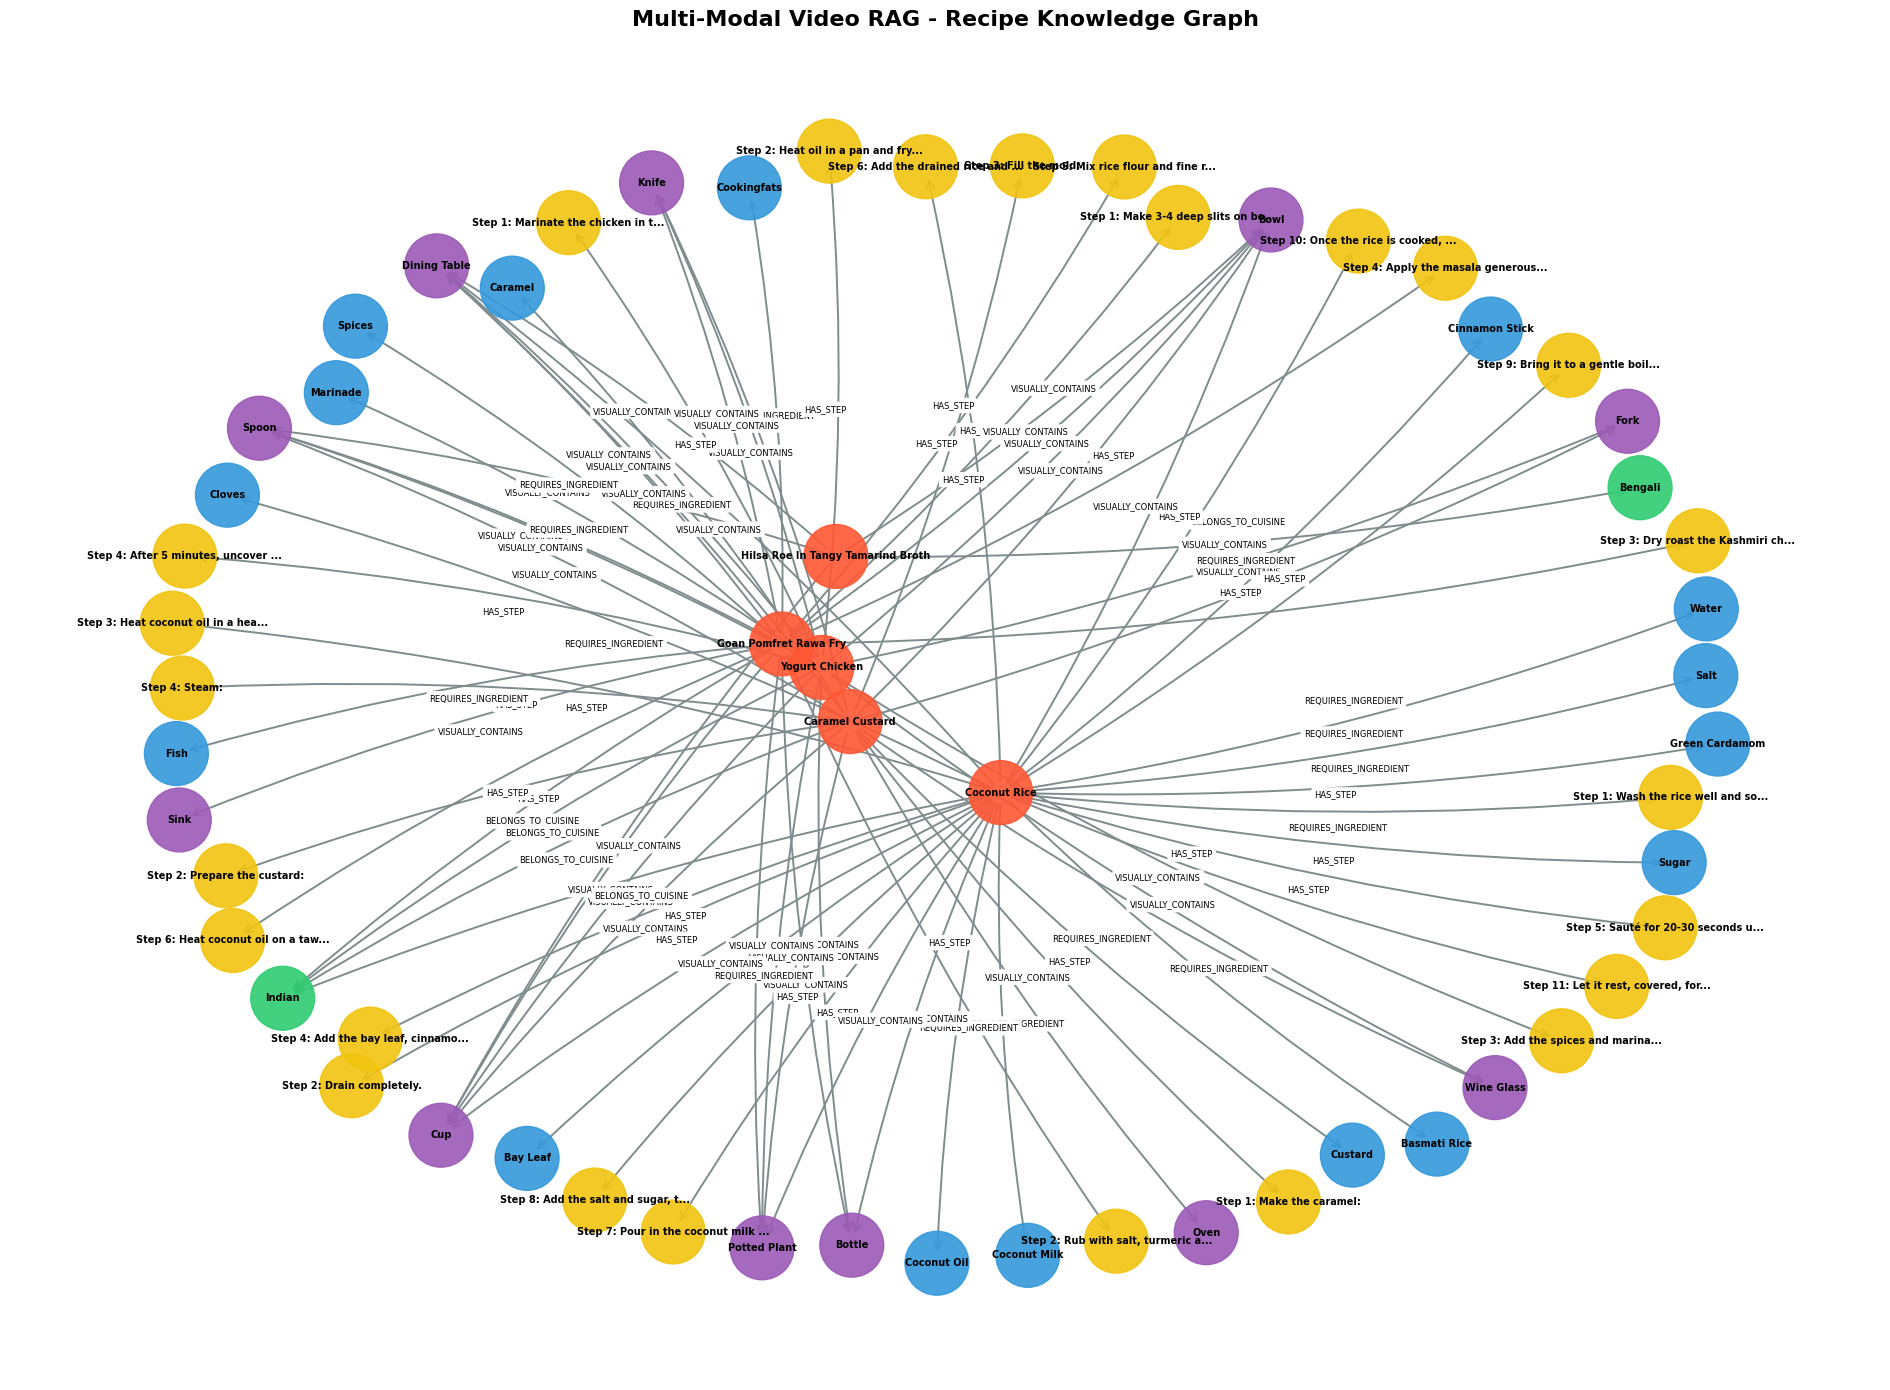

[SUCCESS] Graph plot saved to: /kaggle/working/Video-RAG/Knowledge_Graph/knowledge_graph.png


In [54]:
import os
import glob
import json
import re
import math
import networkx as nx
import matplotlib.pyplot as plt

OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
KG_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "Knowledge_Graph")
os.makedirs(KG_OUTPUT_DIR, exist_ok=True)

# Color Scheme Mapping for Unbiased Entity Typing
ENTITY_COLOR_MAP = {
    "Dish": "#FF5733",        # Vibrant Orange
    "Cuisine": "#2ECC71",     # Emerald Green
    "Ingredient": "#3498DB",  # Dodger Blue
    "Step": "#F1C40F",        # Sunflower Yellow
    "Utensil/Object": "#9B59B6" # Amethyst Purple
}

# Domain-specific noise filters
GENERIC_STOPWORDS = {
    "ingredient", "ingredients", "step", "method", "recipe", 
    "cooking", "preparation", "food", "name", "quantity", "unit", "tsp", "tbsp"
}

# Broad Kitchen/Utensil Registry to preserve genuine visual items across diverse recipes
KITCHEN_CONTEXT_KEYWORDS = {
    "bowl", "knife", "spoon", "fork", "cup", "bottle", "wine glass", "pan", "pot", 
    "oven", "sink", "refrigerator", "dining table", "clock", "spatula", "plate", 
    "blender", "cutting board", "kettle", "toaster", "microwave"
}

def clean_entity_text(text: str) -> str:
    """Cleans up raw strings by removing extra spaces and special characters."""
    if not text:
        return ""
    text = re.sub(r'[\s\_]+', ' ', text).strip()
    return text

def parse_and_normalize_ingredient(raw_ing) -> str:
    """
    Safely extracts and strips quantities, measurements, dict keys, and prep notes 
    from ingredients to create clean entity nodes.
    """
    if isinstance(raw_ing, dict):
        ing_str = raw_ing.get("name") or raw_ing.get("ingredient") or ""
    else:
        ing_str = str(raw_ing)

    ing = ing_str.lower()
    # Remove contents inside parentheses
    ing = re.sub(r'\(.*?\)', '', ing)
    # Remove common metrics and quantities
    ing = re.sub(r'\b(\d+[\d\/\.]*|\d+\s*(g|kg|ml|l|tsp|tbsp|cup|cups|oz|pound|lbs|piece|pieces|clove|cloves|slice|slices))\b', '', ing)
    # Remove common adjective modifiers and dict noise
    ing = re.sub(r'\b(fresh|chopped|minced|diced|sliced|grated|peeled|cooked|raw|optional|to taste|name|quantity|unit)\b', '', ing)
    ing = re.sub(r'[^a-zA-Z\s]', '', ing)
    ing = clean_entity_text(ing)
    return ing.lower() if ing and ing not in GENERIC_STOPWORDS else ""

# Initialize Directed Knowledge Graph
G = nx.DiGraph()

metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))
print(f"[INFO] Building Knowledge Graph from {len(metadata_files)} metadata file(s)...")

for meta_file in metadata_files:
    try:
        with open(meta_file, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARNING] Skipping unreadable file {meta_file}: {e}")
        continue
        
    video_info = data.get("video_info", {})
    recipe_info = data.get("recipe_information", {})
    obj_detections = data.get("object_detection", [])
    
    # Entity Extraction 1: Dish / Primary Video Subject
    # PRIORITY FIX: Use video title first to ensure full, specific dish names
    file_fallback = os.path.basename(meta_file).replace("_metadata.json", "").replace(".json", "")
    video_title = video_info.get("title", "").strip()
    dish_type = recipe_info.get("dish_type", "").strip()
    
    raw_dish = video_title if video_title else (dish_type if dish_type else file_fallback)
    dish_name = clean_entity_text(raw_dish).title()
    
    if not G.has_node(dish_name):
        G.add_node(dish_name, type="Dish", color=ENTITY_COLOR_MAP["Dish"])
        
    # Entity Extraction 2: Cuisine Mapping
    cuisine = recipe_info.get("cuisine", "").strip()
    if cuisine and cuisine.lower() not in {"unknown", "general", "none"}:
        cuisine_name = clean_entity_text(cuisine).title()
        G.add_node(cuisine_name, type="Cuisine", color=ENTITY_COLOR_MAP["Cuisine"])
        G.add_edge(dish_name, cuisine_name, relation="BELONGS_TO_CUISINE")
        
    # Entity Extraction 3: Ingredients Mapping
    ingredients = recipe_info.get("ingredients", [])
    for raw_ing in ingredients:
        clean_ing = parse_and_normalize_ingredient(raw_ing)
        if clean_ing:
            ing_node = clean_ing.title()
            G.add_node(ing_node, type="Ingredient", color=ENTITY_COLOR_MAP["Ingredient"])
            G.add_edge(dish_name, ing_node, relation="REQUIRES_INGREDIENT")
            
    # Entity Extraction 4: Sequential Cooking Steps
    steps = recipe_info.get("estimated_steps", [])
    for idx, step_text in enumerate(steps, start=1):
        clean_step = clean_entity_text(str(step_text))
        if clean_step:
            truncated_text = clean_step[:25] + "..." if len(clean_step) > 25 else clean_step
            # Scoping step node ID by dish name prevents cross-recipe node merging
            step_node_id = f"[{dish_name}] Step {idx}"
            step_display_label = f"Step {idx}: {truncated_text}"
            
            G.add_node(
                step_node_id, 
                label=step_display_label,
                type="Step", 
                color=ENTITY_COLOR_MAP["Step"],
                full_text=clean_step,
                step_number=idx
            )
            G.add_edge(dish_name, step_node_id, relation="HAS_STEP")
            
    # Entity Extraction 5: Visual Objects / Utensils from Keyframes
    detected_classes = set()
    for frame_obj in obj_detections:
        for obj in frame_obj.get("detected_objects", []):
            c_name = obj.get("class_name", "").lower().strip()
            if c_name and (c_name in KITCHEN_CONTEXT_KEYWORDS or "pan" in c_name or "pot" in c_name):
                detected_classes.add(c_name)
                
    for obj_name in detected_classes:
        obj_node = obj_name.title()
        G.add_node(obj_node, type="Utensil/Object", color=ENTITY_COLOR_MAP["Utensil/Object"])
        G.add_edge(dish_name, obj_node, relation="VISUALLY_CONTAINS")

print(f"[SUCCESS] Knowledge Graph Created!")
print(f"Total Nodes: {G.number_of_nodes()} | Total Edges: {G.number_of_edges()}")

# Graph Persistence (GraphML Export)
graphml_path = os.path.join(KG_OUTPUT_DIR, "video_rag_kg.graphml")
nx.write_graphml(G, graphml_path)
print(f"[SUCCESS] Exported GraphML file to: {graphml_path}")

# Static Plot Generation (Matplotlib Visualization)
num_nodes = G.number_of_nodes()
fig_size = max(16, int(math.sqrt(num_nodes) * 2.5))
plt.figure(figsize=(fig_size, int(fig_size * 0.75)))

# Dynamic spring layout repulsion coefficient based on node density
layout_k = max(0.8, 3.8 / math.sqrt(num_nodes if num_nodes > 0 else 1))
pos = nx.spring_layout(G, k=layout_k, iterations=150, seed=42)

# Extract node colors dynamically from type attributes
colors = [data.get("color", "#999999") for _, data in G.nodes(data=True)]

# Display full node ID or friendly step display label
node_labels = {node: data.get("label", node) for node, data in G.nodes(data=True)}

# Render Graph Components
nx.draw_networkx_nodes(G, pos, node_size=max(1600, 3000 - num_nodes * 15), node_color=colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=14, edge_color="#7F8C8D", width=1.4, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=max(6, 9 - int(num_nodes / 25)), font_weight="bold")

# Edge Relation Labels
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=max(5, 7 - int(num_nodes / 30)), rotate=False)

plt.title("Multi-Modal Video RAG - Recipe Knowledge Graph", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()

kg_image_path = os.path.join(KG_OUTPUT_DIR, "knowledge_graph.png")
plt.savefig(kg_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SUCCESS] Graph plot saved to: {kg_image_path}")

[INFO] Building Knowledge Graph from 5 metadata file(s)...
[SUCCESS] Knowledge Graph Created!
Total Nodes: 59 | Total Edges: 81


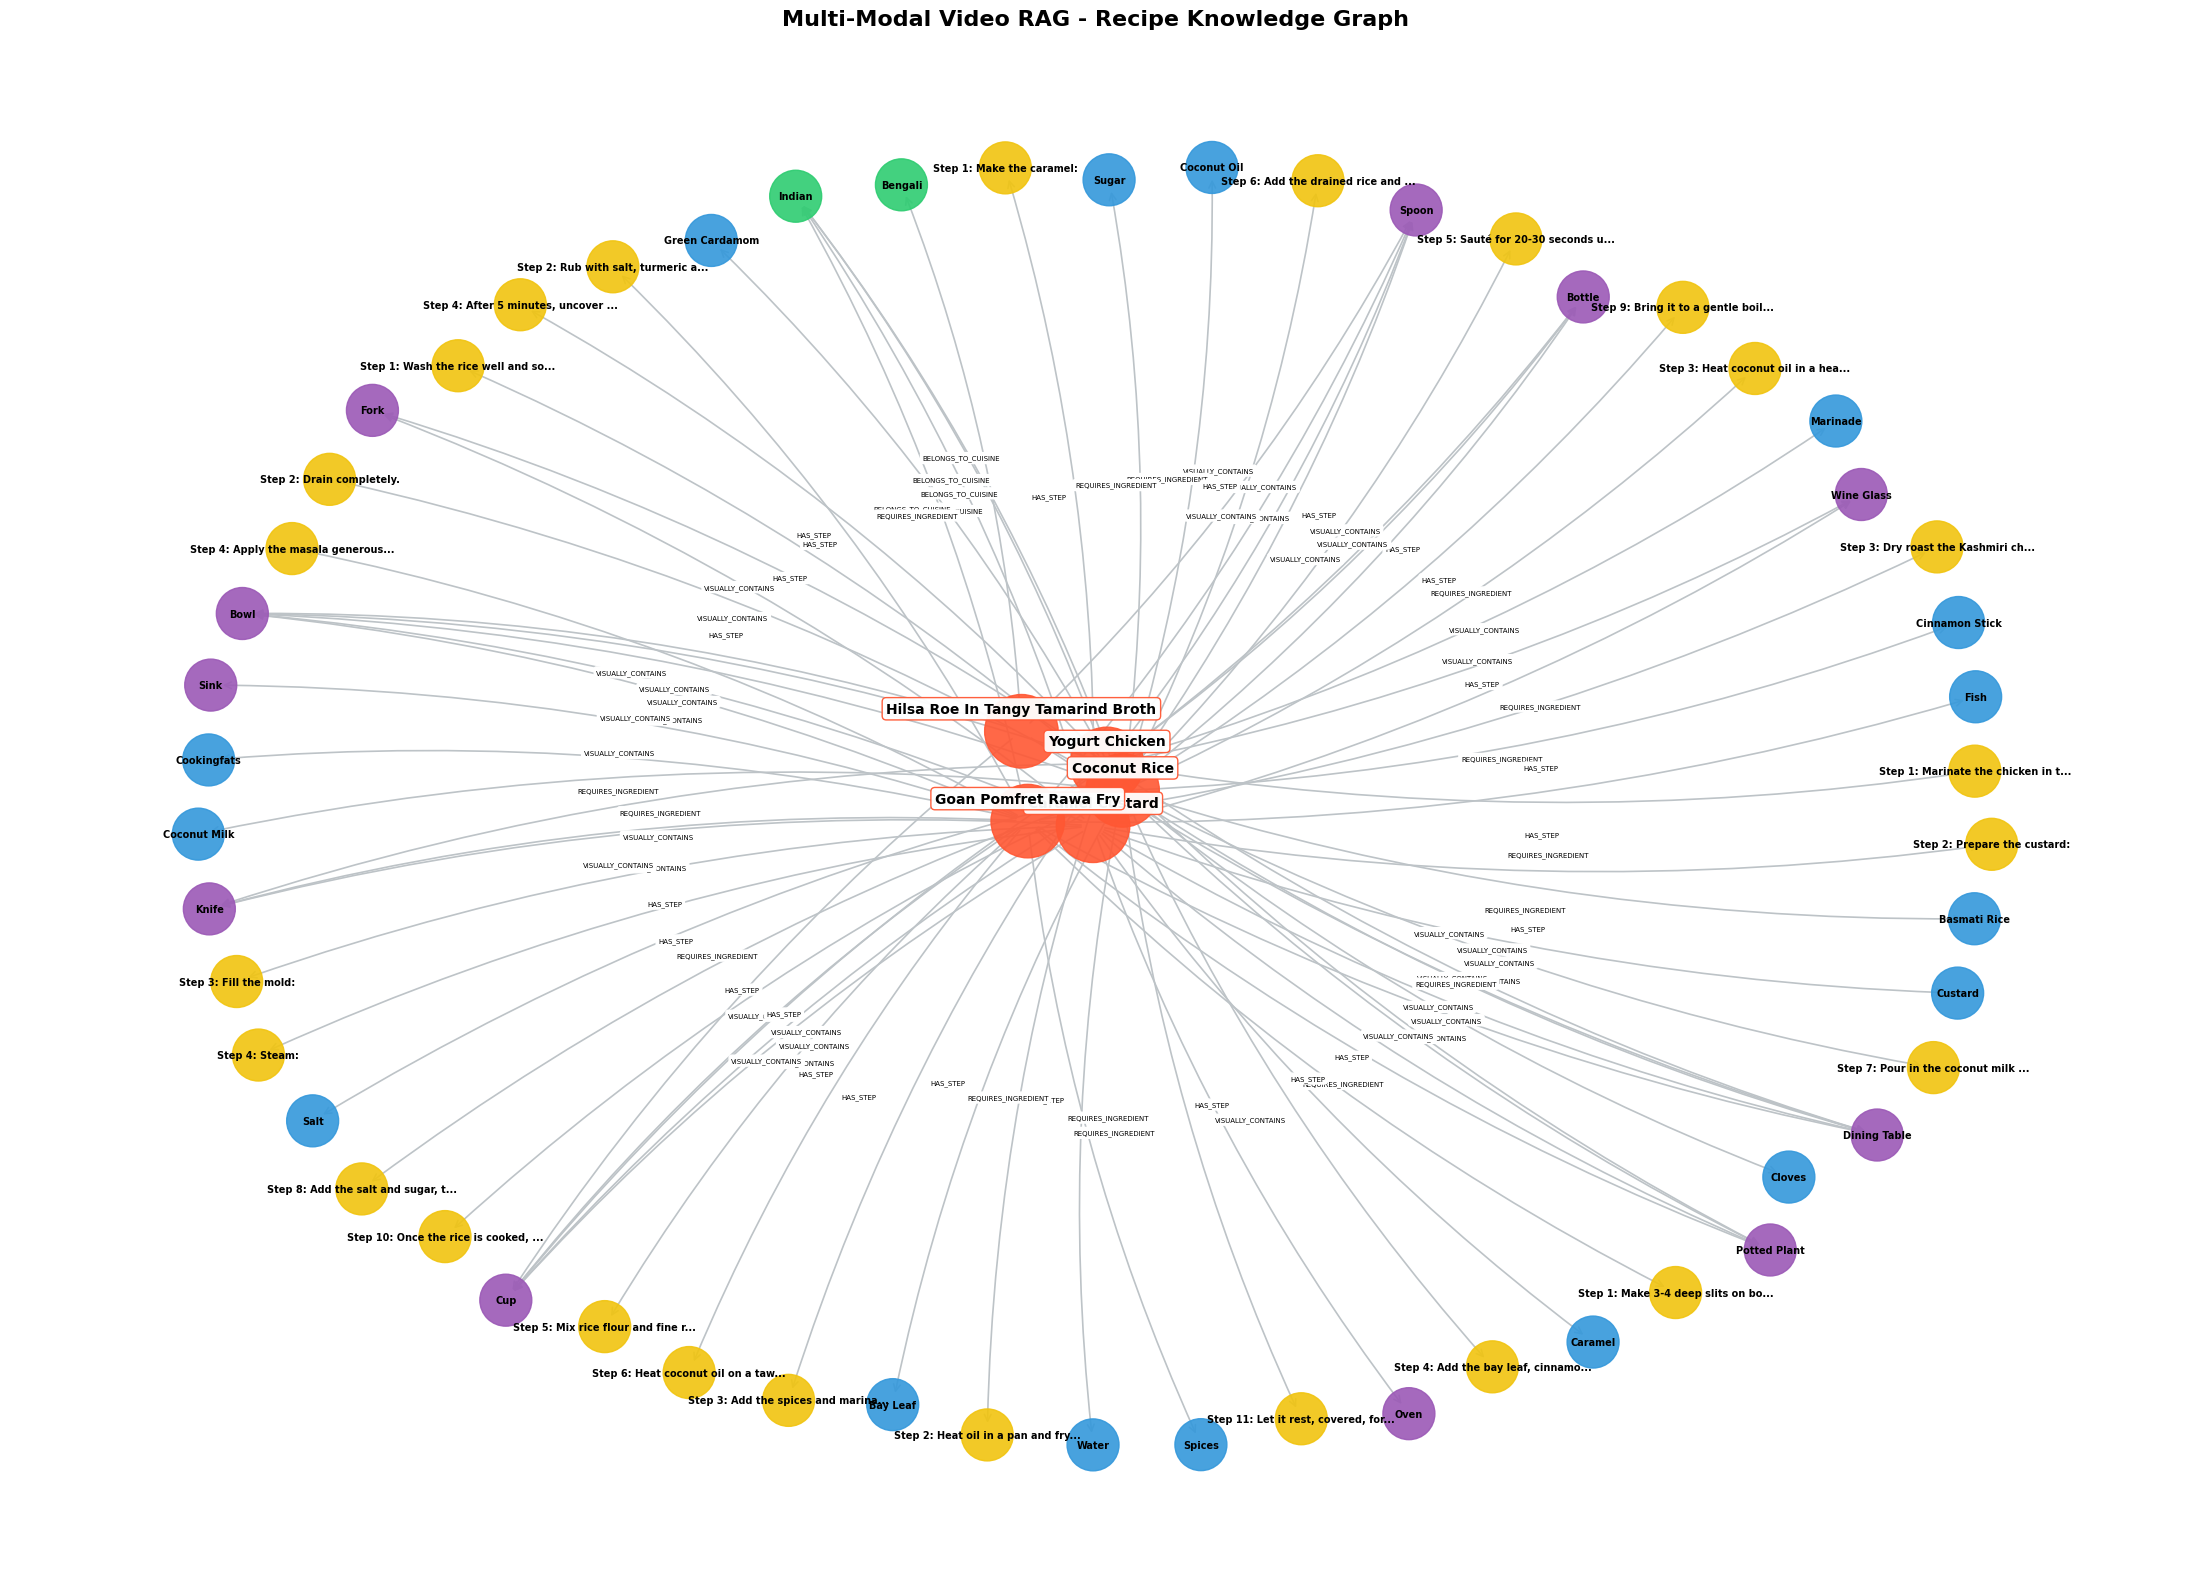

[SUCCESS] Clean, non-overlapping graph plot saved to: /kaggle/working/Video-RAG/Knowledge_Graph/knowledge_graph.png


In [55]:
import os
import glob
import json
import re
import math
import networkx as nx
import matplotlib.pyplot as plt

OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
KG_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "Knowledge_Graph")
os.makedirs(KG_OUTPUT_DIR, exist_ok=True)

ENTITY_COLOR_MAP = {
    "Dish": "#FF5733",        # Vibrant Orange
    "Cuisine": "#2ECC71",     # Emerald Green
    "Ingredient": "#3498DB",  # Dodger Blue
    "Step": "#F1C40F",        # Sunflower Yellow
    "Utensil/Object": "#9B59B6" # Amethyst Purple
}

GENERIC_STOPWORDS = {
    "ingredient", "ingredients", "step", "method", "recipe", 
    "cooking", "preparation", "food", "name", "quantity", "unit", "tsp", "tbsp"
}

KITCHEN_CONTEXT_KEYWORDS = {
    "bowl", "knife", "spoon", "fork", "cup", "bottle", "wine glass", "pan", "pot", 
    "oven", "sink", "refrigerator", "dining table", "clock", "spatula", "plate", 
    "blender", "cutting board", "kettle", "toaster", "microwave"
}

def clean_entity_text(text: str) -> str:
    if not text:
        return ""
    text = re.sub(r'[\s\_]+', ' ', text).strip()
    return text

def parse_and_normalize_ingredient(raw_ing) -> str:
    if isinstance(raw_ing, dict):
        ing_str = raw_ing.get("name") or raw_ing.get("ingredient") or ""
    else:
        ing_str = str(raw_ing)

    ing = ing_str.lower()
    ing = re.sub(r'\(.*?\)', '', ing)
    ing = re.sub(r'\b(\d+[\d\/\.]*|\d+\s*(g|kg|ml|l|tsp|tbsp|cup|cups|oz|pound|lbs|piece|pieces|clove|cloves|slice|slices))\b', '', ing)
    ing = re.sub(r'\b(fresh|chopped|minced|diced|sliced|grated|peeled|cooked|raw|optional|to taste|name|quantity|unit)\b', '', ing)
    ing = re.sub(r'[^a-zA-Z\s]', '', ing)
    ing = clean_entity_text(ing)
    return ing.lower() if ing and ing not in GENERIC_STOPWORDS else ""

G = nx.DiGraph()

metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))
print(f"[INFO] Building Knowledge Graph from {len(metadata_files)} metadata file(s)...")

for meta_file in metadata_files:
    try:
        with open(meta_file, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARNING] Skipping unreadable file {meta_file}: {e}")
        continue
        
    video_info = data.get("video_info", {})
    recipe_info = data.get("recipe_information", {})
    obj_detections = data.get("object_detection", [])
    
    file_fallback = os.path.basename(meta_file).replace("_metadata.json", "").replace(".json", "")
    video_title = video_info.get("title", "").strip()
    dish_type = recipe_info.get("dish_type", "").strip()
    
    raw_dish = video_title if video_title else (dish_type if dish_type else file_fallback)
    dish_name = clean_entity_text(raw_dish).title()
    
    if not G.has_node(dish_name):
        G.add_node(dish_name, type="Dish", color=ENTITY_COLOR_MAP["Dish"])
        
    cuisine = recipe_info.get("cuisine", "").strip()
    if cuisine and cuisine.lower() not in {"unknown", "general", "none"}:
        cuisine_name = clean_entity_text(cuisine).title()
        G.add_node(cuisine_name, type="Cuisine", color=ENTITY_COLOR_MAP["Cuisine"])
        G.add_edge(dish_name, cuisine_name, relation="BELONGS_TO_CUISINE")
        
    ingredients = recipe_info.get("ingredients", [])
    for raw_ing in ingredients:
        clean_ing = parse_and_normalize_ingredient(raw_ing)
        if clean_ing:
            ing_node = clean_ing.title()
            G.add_node(ing_node, type="Ingredient", color=ENTITY_COLOR_MAP["Ingredient"])
            G.add_edge(dish_name, ing_node, relation="REQUIRES_INGREDIENT")
            
    steps = recipe_info.get("estimated_steps", [])
    for idx, step_text in enumerate(steps, start=1):
        clean_step = clean_entity_text(str(step_text))
        if clean_step:
            truncated_text = clean_step[:25] + "..." if len(clean_step) > 25 else clean_step
            step_node_id = f"[{dish_name}] Step {idx}"
            step_display_label = f"Step {idx}: {truncated_text}"
            
            G.add_node(
                step_node_id, 
                label=step_display_label,
                type="Step", 
                color=ENTITY_COLOR_MAP["Step"],
                full_text=clean_step,
                step_number=idx
            )
            G.add_edge(dish_name, step_node_id, relation="HAS_STEP")
            
    detected_classes = set()
    for frame_obj in obj_detections:
        for obj in frame_obj.get("detected_objects", []):
            c_name = obj.get("class_name", "").lower().strip()
            if c_name and (c_name in KITCHEN_CONTEXT_KEYWORDS or "pan" in c_name or "pot" in c_name):
                detected_classes.add(c_name)
                
    for obj_name in detected_classes:
        obj_node = obj_name.title()
        G.add_node(obj_node, type="Utensil/Object", color=ENTITY_COLOR_MAP["Utensil/Object"])
        G.add_edge(dish_name, obj_node, relation="VISUALLY_CONTAINS")

print(f"[SUCCESS] Knowledge Graph Created!")
print(f"Total Nodes: {G.number_of_nodes()} | Total Edges: {G.number_of_edges()}")

# Export GraphML
graphml_path = os.path.join(KG_OUTPUT_DIR, "video_rag_kg.graphml")
nx.write_graphml(G, graphml_path)

# --- VISUALIZATION OVERLAP FIX ---
num_nodes = G.number_of_nodes()
plt.figure(figsize=(22, 16))

# 1. Higher 'k' value forces central dish nodes further apart
pos = nx.spring_layout(G, k=6.0 / math.sqrt(num_nodes), iterations=250, seed=100)

colors = [data.get("color", "#999999") for _, data in G.nodes(data=True)]

# Render Nodes & Edges
nx.draw_networkx_nodes(G, pos, node_size=[2800 if data.get("type") == "Dish" else 1400 for _, data in G.nodes(data=True)], node_color=colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="#BDC3C7", width=1.2, connectionstyle="arc3,rad=0.08")

# 2. Offset dish labels so text doesn't overlap centered node circles
non_dish_labels = {}
dish_labels = {}

for node, data in G.nodes(data=True):
    label_text = data.get("label", node)
    if data.get("type") == "Dish":
        dish_labels[node] = label_text
    else:
        non_dish_labels[node] = label_text

# Draw non-dish labels centered on their nodes
nx.draw_networkx_labels(G, pos, labels=non_dish_labels, font_size=7, font_weight="bold")

# Draw Dish labels with a slight vertical offset and distinct box styling for readability
dish_pos = {node: (coords[0], coords[1] + 0.035) for node, coords in pos.items() if node in dish_labels}
for node, (x, y) in dish_pos.items():
    plt.text(x, y, dish_labels[node], fontsize=10, fontweight="bold", ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="#FF5733", facecolor="#FFFFFF", alpha=0.95))

# Draw Edge Relations
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5, rotate=False)

plt.title("Multi-Modal Video RAG - Recipe Knowledge Graph", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()

kg_image_path = os.path.join(KG_OUTPUT_DIR, "knowledge_graph.png")
plt.savefig(kg_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SUCCESS] Clean, non-overlapping graph plot saved to: {kg_image_path}")

[INFO] Building Knowledge Graph from 5 metadata file(s)...
[SUCCESS] Knowledge Graph Created!
Total Nodes: 59 | Total Edges: 81
[SUCCESS] Exported GraphML file to: /kaggle/working/Video-RAG/Knowledge_Graph/video_rag_kg.graphml


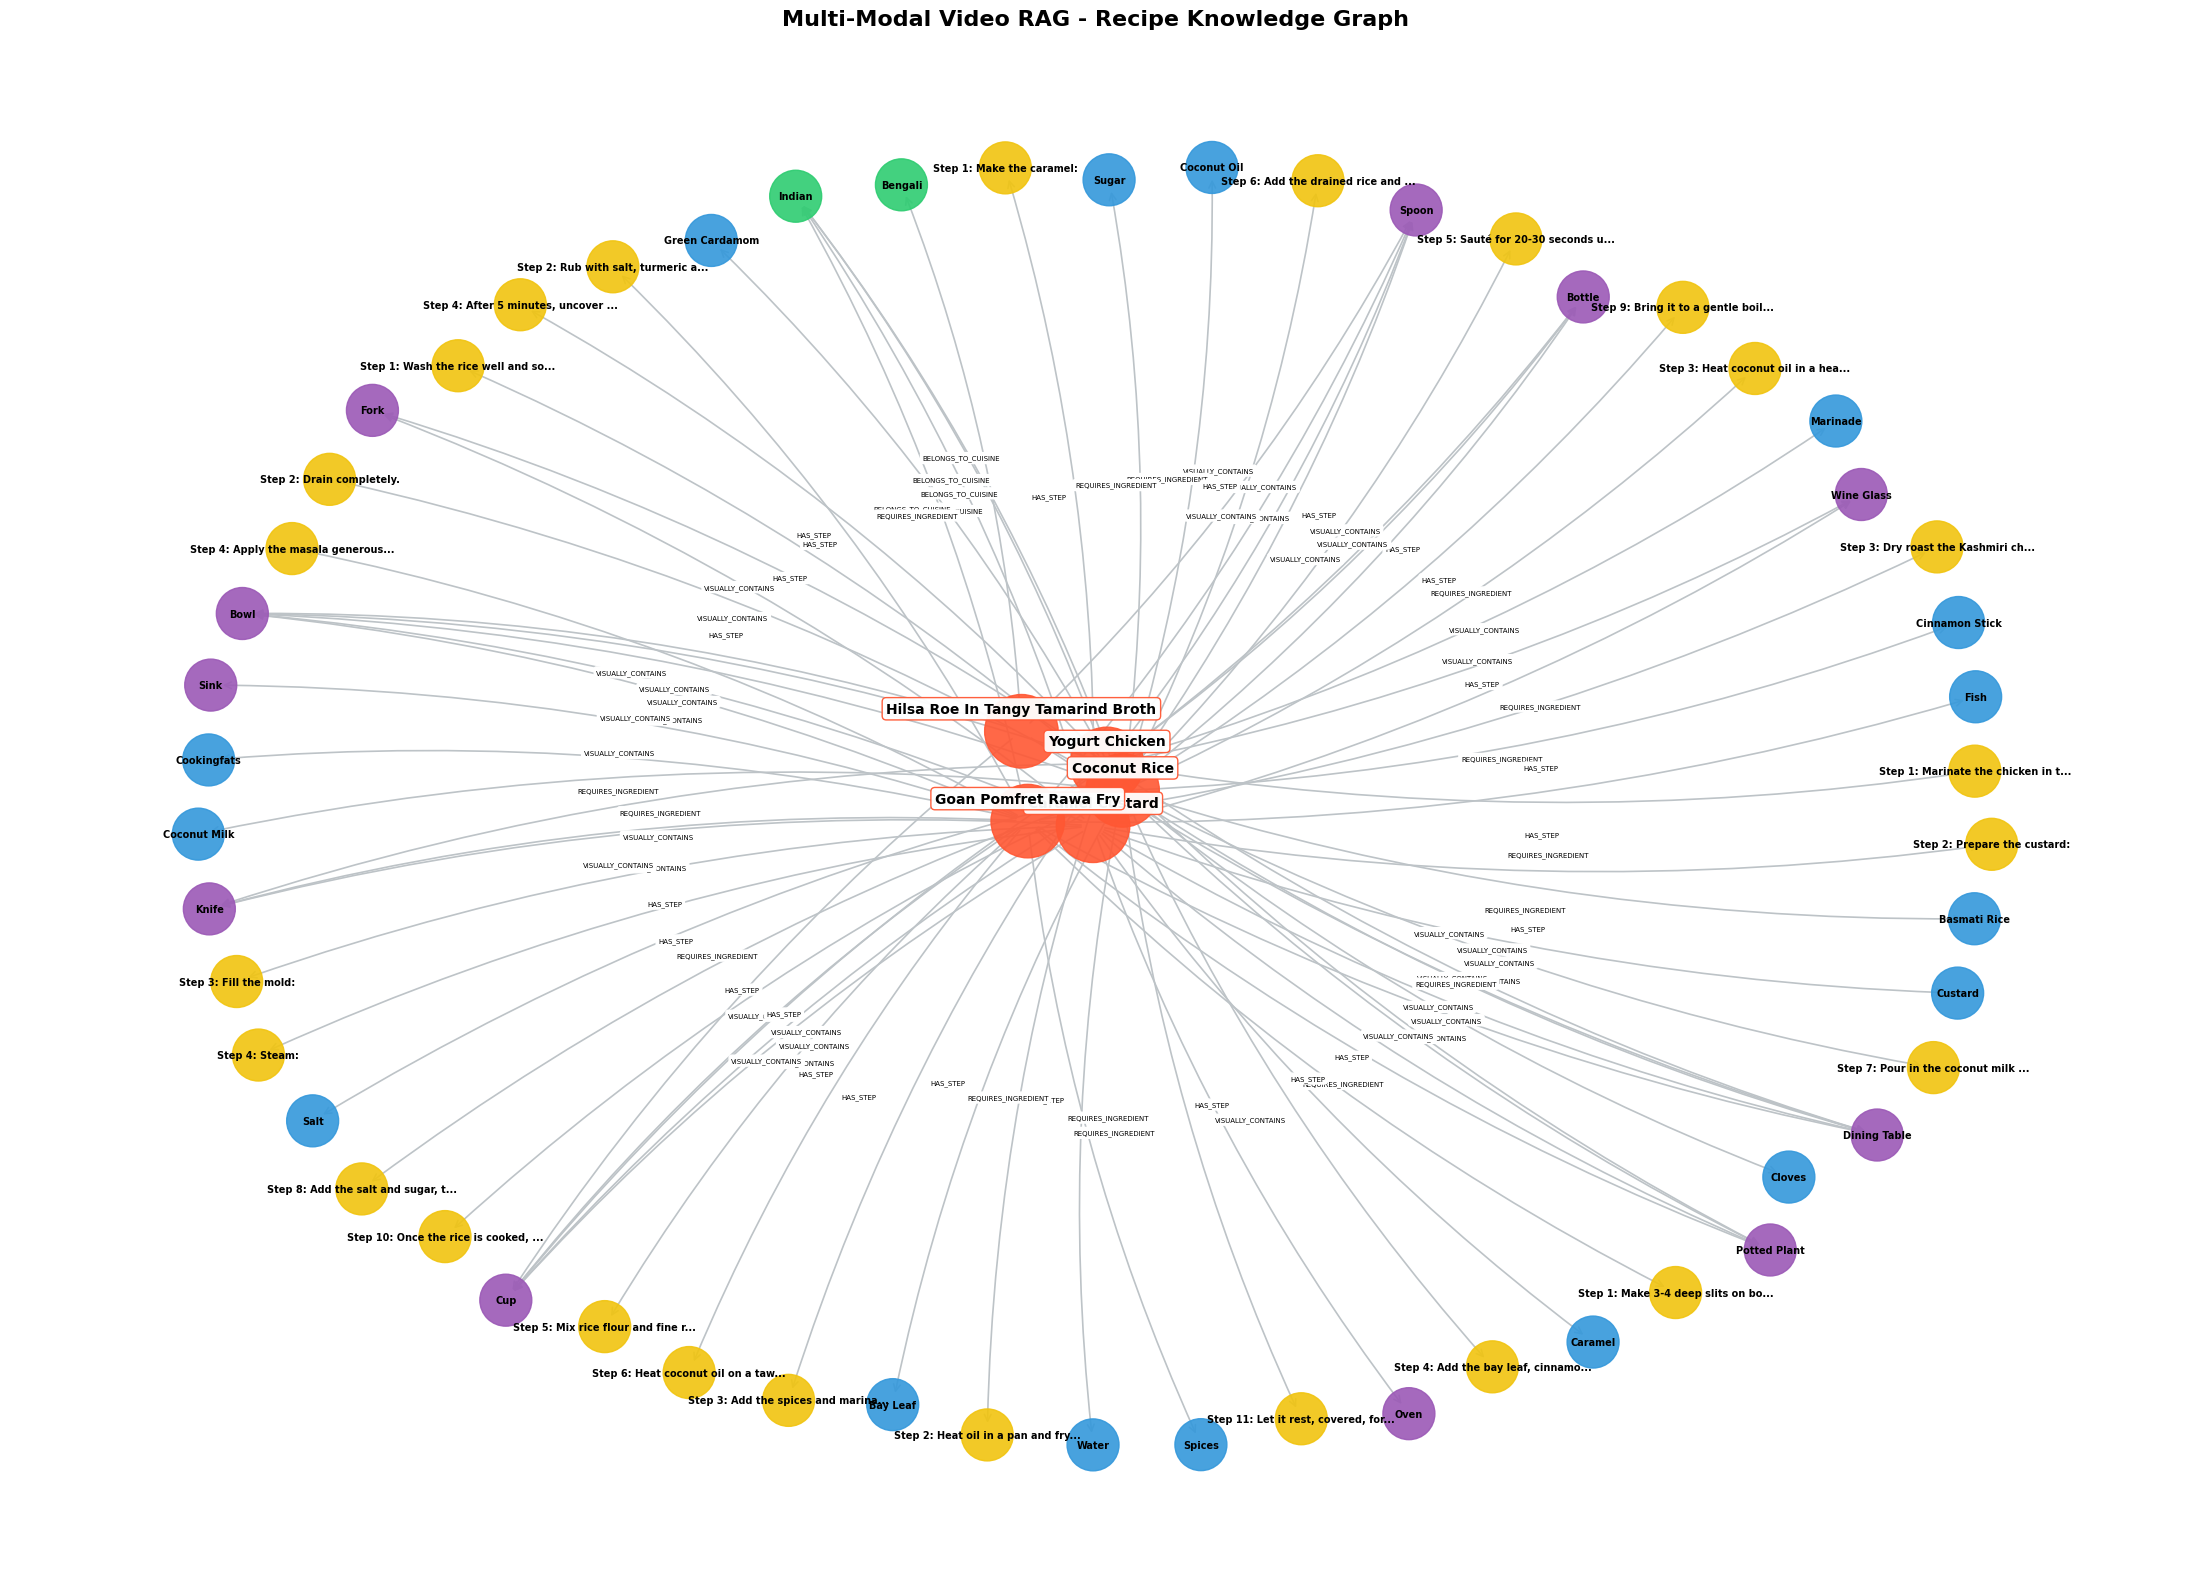

[SUCCESS] Clean, non-overlapping graph plot saved to: /kaggle/working/Video-RAG/Knowledge_Graph/knowledge_graph.png


In [56]:
import os
import glob
import json
import re
import math
import networkx as nx
import matplotlib.pyplot as plt

OUTPUT_DIR = "/kaggle/working/Video-RAG"
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
KG_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "Knowledge_Graph")
os.makedirs(KG_OUTPUT_DIR, exist_ok=True)

# Color Scheme Mapping for Unbiased Entity Typing
ENTITY_COLOR_MAP = {
    "Dish": "#FF5733",        # Vibrant Orange
    "Cuisine": "#2ECC71",     # Emerald Green
    "Ingredient": "#3498DB",  # Dodger Blue
    "Step": "#F1C40F",        # Sunflower Yellow
    "Utensil/Object": "#9B59B6" # Amethyst Purple
}

# Domain-specific noise filters
GENERIC_STOPWORDS = {
    "ingredient", "ingredients", "step", "method", "recipe", 
    "cooking", "preparation", "food", "name", "quantity", "unit", "tsp", "tbsp"
}

# Broad Kitchen/Utensil Registry to preserve genuine visual items across diverse recipes
KITCHEN_CONTEXT_KEYWORDS = {
    "bowl", "knife", "spoon", "fork", "cup", "bottle", "wine glass", "pan", "pot", 
    "oven", "sink", "refrigerator", "dining table", "clock", "spatula", "plate", 
    "blender", "cutting board", "kettle", "toaster", "microwave"
}

def clean_entity_text(text: str) -> str:
    """Cleans up raw strings by removing extra spaces and special characters."""
    if not text:
        return ""
    text = re.sub(r'[\s\_]+', ' ', text).strip()
    return text

def parse_and_normalize_ingredient(raw_ing) -> str:
    """
    Safely extracts and strips quantities, measurements, dict keys, and prep notes 
    from ingredients to create clean entity nodes.
    """
    if isinstance(raw_ing, dict):
        ing_str = raw_ing.get("name") or raw_ing.get("ingredient") or ""
    else:
        ing_str = str(raw_ing)

    ing = ing_str.lower()
    # Remove contents inside parentheses
    ing = re.sub(r'\(.*?\)', '', ing)
    # Remove common metrics and quantities
    ing = re.sub(r'\b(\d+[\d\/\.]*|\d+\s*(g|kg|ml|l|tsp|tbsp|cup|cups|oz|pound|lbs|piece|pieces|clove|cloves|slice|slices))\b', '', ing)
    # Remove common adjective modifiers and dict noise
    ing = re.sub(r'\b(fresh|chopped|minced|diced|sliced|grated|peeled|cooked|raw|optional|to taste|name|quantity|unit)\b', '', ing)
    ing = re.sub(r'[^a-zA-Z\s]', '', ing)
    ing = clean_entity_text(ing)
    return ing.lower() if ing and ing not in GENERIC_STOPWORDS else ""

# Initialize Directed Knowledge Graph
G = nx.DiGraph()

metadata_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))
print(f"[INFO] Building Knowledge Graph from {len(metadata_files)} metadata file(s)...")

for meta_file in metadata_files:
    try:
        with open(meta_file, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARNING] Skipping unreadable file {meta_file}: {e}")
        continue
        
    video_info = data.get("video_info", {})
    recipe_info = data.get("recipe_information", {})
    obj_detections = data.get("object_detection", [])
    
    # Entity Extraction 1: Dish / Primary Video Subject
    file_fallback = os.path.basename(meta_file).replace("_metadata.json", "").replace(".json", "")
    video_title = video_info.get("title", "").strip()
    dish_type = recipe_info.get("dish_type", "").strip()
    
    raw_dish = video_title if video_title else (dish_type if dish_type else file_fallback)
    dish_name = clean_entity_text(raw_dish).title()
    
    if not G.has_node(dish_name):
        G.add_node(dish_name, type="Dish", color=ENTITY_COLOR_MAP["Dish"])
        
    # Entity Extraction 2: Cuisine Mapping
    cuisine = recipe_info.get("cuisine", "").strip()
    if cuisine and cuisine.lower() not in {"unknown", "general", "none"}:
        cuisine_name = clean_entity_text(cuisine).title()
        G.add_node(cuisine_name, type="Cuisine", color=ENTITY_COLOR_MAP["Cuisine"])
        G.add_edge(dish_name, cuisine_name, relation="BELONGS_TO_CUISINE")
        
    # Entity Extraction 3: Ingredients Mapping
    ingredients = recipe_info.get("ingredients", [])
    for raw_ing in ingredients:
        clean_ing = parse_and_normalize_ingredient(raw_ing)
        if clean_ing:
            ing_node = clean_ing.title()
            G.add_node(ing_node, type="Ingredient", color=ENTITY_COLOR_MAP["Ingredient"])
            G.add_edge(dish_name, ing_node, relation="REQUIRES_INGREDIENT")
            
    # Entity Extraction 4: Sequential Cooking Steps
    steps = recipe_info.get("estimated_steps", [])
    for idx, step_text in enumerate(steps, start=1):
        clean_step = clean_entity_text(str(step_text))
        if clean_step:
            truncated_text = clean_step[:25] + "..." if len(clean_step) > 25 else clean_step
            step_node_id = f"[{dish_name}] Step {idx}"
            step_display_label = f"Step {idx}: {truncated_text}"
            
            G.add_node(
                step_node_id, 
                label=step_display_label,
                type="Step", 
                color=ENTITY_COLOR_MAP["Step"],
                full_text=clean_step,
                step_number=idx
            )
            G.add_edge(dish_name, step_node_id, relation="HAS_STEP")
            
    # Entity Extraction 5: Visual Objects / Utensils from Keyframes
    detected_classes = set()
    for frame_obj in obj_detections:
        for obj in frame_obj.get("detected_objects", []):
            c_name = obj.get("class_name", "").lower().strip()
            if c_name and (c_name in KITCHEN_CONTEXT_KEYWORDS or "pan" in c_name or "pot" in c_name):
                detected_classes.add(c_name)
                
    for obj_name in detected_classes:
        obj_node = obj_name.title()
        G.add_node(obj_node, type="Utensil/Object", color=ENTITY_COLOR_MAP["Utensil/Object"])
        G.add_edge(dish_name, obj_node, relation="VISUALLY_CONTAINS")

print(f"[SUCCESS] Knowledge Graph Created!")
print(f"Total Nodes: {G.number_of_nodes()} | Total Edges: {G.number_of_edges()}")

# Graph Persistence (GraphML Export)
graphml_path = os.path.join(KG_OUTPUT_DIR, "video_rag_kg.graphml")
nx.write_graphml(G, graphml_path)
print(f"[SUCCESS] Exported GraphML file to: {graphml_path}")

# Static Plot Generation (Matplotlib Visualization with Label Anti-Collision)
num_nodes = G.number_of_nodes()
plt.figure(figsize=(22, 16))

# Higher 'k' forces central dish nodes further apart to avoid label overlap
pos = nx.spring_layout(G, k=6.0 / math.sqrt(num_nodes if num_nodes > 0 else 1), iterations=250, seed=100)

colors = [data.get("color", "#999999") for _, data in G.nodes(data=True)]

# Render Nodes & Edges
nx.draw_networkx_nodes(G, pos, node_size=[2800 if data.get("type") == "Dish" else 1400 for _, data in G.nodes(data=True)], node_color=colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="#BDC3C7", width=1.2, connectionstyle="arc3,rad=0.08")

# Separate Dish labels from non-dish labels for offset rendering
non_dish_labels = {}
dish_labels = {}

for node, data in G.nodes(data=True):
    label_text = data.get("label", node)
    if data.get("type") == "Dish":
        dish_labels[node] = label_text
    else:
        non_dish_labels[node] = label_text

# Draw non-dish labels
nx.draw_networkx_labels(G, pos, labels=non_dish_labels, font_size=7, font_weight="bold")

# Draw Dish labels with vertical offset & bounding box callouts
dish_pos = {node: (coords[0], coords[1] + 0.035) for node, coords in pos.items() if node in dish_labels}
for node, (x, y) in dish_pos.items():
    plt.text(x, y, dish_labels[node], fontsize=10, fontweight="bold", ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="#FF5733", facecolor="#FFFFFF", alpha=0.95))

# Draw Edge Relations
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5, rotate=False)

plt.title("Multi-Modal Video RAG - Recipe Knowledge Graph", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()

kg_image_path = os.path.join(KG_OUTPUT_DIR, "knowledge_graph.png")
plt.savefig(kg_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SUCCESS] Clean, non-overlapping graph plot saved to: {kg_image_path}")

### Step 6: Knowledge Graph Traversal & Relational Retrieval

* **Persisted Graph Ingestion:**
  * Imports and validates the serialized GraphML file (`video_rag_kg.graphml`) from `/Knowledge_Graph` into memory as a NetworkX directed graph object (`nx.DiGraph`).
* **Multi-Attribute Entity Matcher:**
  * Implements `search_graph_structure()` to execute case-insensitive, fuzzy substring matching across node keys and internal metadata attributes (`label`, `full_text`).
* **Multi-Hop Traversal Architecture:**
  * **1-Hop Traversal:** Retrieves direct inbound (`predecessors`) and outbound (`successors`) directional connections for all matched entities.
  * **2-Hop Context Expansion:** Identifies primary `Dish` hubs (or structural fallbacks with `HAS_STEP` edges) to extract complete recipe sibling contexts—pulling all linked Cuisines, Ingredients, Cooking Steps, and Visual Utensils.
* **Triple Normalization & Priority Sorting:**
  * Deduplicates extracted `(source, relation, target)` relationship triples.
  * Sorts triples by logical domain priority (`BELONGS_TO_CUISINE` $\rightarrow$ `REQUIRES_INGREDIENT` $\rightarrow$ `HAS_STEP` $\rightarrow$ `VISUALLY_CONTAINS`) to format clean structural context for downstream LLM generation prompts.

In [58]:
import os
import re
import networkx as nx

OUTPUT_DIR = "/kaggle/working/Video-RAG"
KG_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "Knowledge_Graph")
GRAPHML_PATH = os.path.join(KG_OUTPUT_DIR, "video_rag_kg.graphml")

# 1. Load Persisted Knowledge Graph
if os.path.exists(GRAPHML_PATH):
    KG = nx.read_graphml(GRAPHML_PATH)
    print(f"[SUCCESS] Loaded Knowledge Graph ({KG.number_of_nodes()} nodes, {KG.number_of_edges()} edges).")
else:
    raise FileNotFoundError(f"Graph file not found at {GRAPHML_PATH}. Ensure the KG construction step was executed.")

# 2. Fully Unbiased Robust Graph Traversal Function
def search_graph_structure(entities: list, depth: int = 2):
    """
    Traverses the Knowledge Graph starting from any arbitrary input entity nodes.
    Performs case-insensitive substring matching against node keys and attributes,
    followed by multi-hop retrieval to extract full recipe contexts.
    """
    discovered_relationships = []
    processed_recipes = set()
    
    for entity in entities:
        if not entity or not str(entity).strip():
            continue
            
        clean_entity = str(entity).strip().lower()
        
        # Robust entity matching: Check node ID string and attribute values (label, full_text, etc.)
        matched_nodes = []
        for node, attrs in KG.nodes(data=True):
            node_str = str(node).lower()
            label_str = str(attrs.get("label", "") or "").lower()
            text_str = str(attrs.get("full_text", "") or "").lower()
            
            if clean_entity in node_str or clean_entity in label_str or clean_entity in text_str:
                matched_nodes.append(node)
        
        for node in matched_nodes:
            # --- 1-Hop Traversal: Direct Inbound Connections ---
            parents = list(KG.predecessors(node))
            for source in parents:
                edge_data = KG.get_edge_data(source, node) or {}
                rel = edge_data.get("relation", "RELATED_TO")
                discovered_relationships.append({
                    "source": source,
                    "relation": rel,
                    "target": node,
                    "direction": "inbound"
                })

            # --- 1-Hop Traversal: Direct Outbound Connections ---
            children = list(KG.successors(node))
            for target in children:
                edge_data = KG.get_edge_data(node, target) or {}
                rel = edge_data.get("relation", "RELATED_TO")
                discovered_relationships.append({
                    "source": node,
                    "relation": rel,
                    "target": target,
                    "direction": "outbound"
                })

            # --- 2-Hop Traversal: Full Context Expansion ---
            if depth >= 2:
                recipe_candidates = []
                
                # Check if current node is a primary Dish entity
                if KG.nodes[node].get("type") == "Dish":
                    recipe_candidates.append(node)
                
                # Trace back to parent Dish entities
                for parent in parents:
                    if KG.nodes[parent].get("type") == "Dish":
                        recipe_candidates.append(parent)
                
                # Fallback: Treat any node with outgoing HAS_STEP as a Dish hub
                if not recipe_candidates:
                    for cand in [node] + parents:
                        out_rels = [KG.get_edge_data(cand, succ, {}).get("relation") for succ in KG.successors(cand)]
                        if "HAS_STEP" in out_rels:
                            recipe_candidates.append(cand)

                for recipe in recipe_candidates:
                    if recipe in processed_recipes:
                        continue
                    
                    recipe_outbound = list(KG.successors(recipe))
                    if recipe_outbound:
                        processed_recipes.add(recipe)
                        
                        # Pull all sibling entities (Steps, Ingredients, Cuisine, Objects)
                        for sibling in recipe_outbound:
                            edge_data = KG.get_edge_data(recipe, sibling) or {}
                            rel = edge_data.get("relation", "RELATED_TO")
                            discovered_relationships.append({
                                "source": recipe,
                                "relation": rel,
                                "target": sibling,
                                "direction": "2hop_recipe_context"
                            })

    # Deduplicate relationship triples
    unique_relationships = []
    seen = set()
    for rel in discovered_relationships:
        triple = (rel["source"], rel["relation"], rel["target"])
        if triple not in seen:
            seen.add(triple)
            unique_relationships.append(rel)

    # Sort relationships logically
    relation_priority = {
        "BELONGS_TO_CUISINE": 1,
        "REQUIRES_INGREDIENT": 2,
        "HAS_STEP": 3,
        "VISUALLY_CONTAINS": 4
    }
    
    unique_relationships.sort(
        key=lambda x: (x["source"], relation_priority.get(x["relation"], 99), str(x["target"]))
    )

    return unique_relationships

# --- User Interactive Input ---
user_input = input("Enter search entities (separated by commas, e.g. Chicken, Pan, Rice): ")
test_entities = [e.strip() for e in user_input.split(",") if e.strip()]

if test_entities:
    graph_results = search_graph_structure(test_entities, depth=2)

    print(f"\n--- Graph Structural Relationships Retrieved for: {test_entities} ---")
    if not graph_results:
        print("No matching graph entities found.")
    else:
        for rel in graph_results:
            print(f"[{rel['source']}] --({rel['relation']})--> [{rel['target']}]")
else:
    print("No entities entered.")

[SUCCESS] Loaded Knowledge Graph (59 nodes, 81 edges).


Enter search entities (separated by commas, e.g. Chicken, Pan, Rice):  garlic, pasta, cooking, pan, custard, rice



--- Graph Structural Relationships Retrieved for: ['garlic', 'pasta', 'cooking', 'pan', 'custard', 'rice'] ---
[Caramel Custard] --(BELONGS_TO_CUISINE)--> [Indian]
[Caramel Custard] --(REQUIRES_INGREDIENT)--> [Caramel]
[Caramel Custard] --(REQUIRES_INGREDIENT)--> [Custard]
[Caramel Custard] --(HAS_STEP)--> [[Caramel Custard] Step 1]
[Caramel Custard] --(HAS_STEP)--> [[Caramel Custard] Step 2]
[Caramel Custard] --(HAS_STEP)--> [[Caramel Custard] Step 3]
[Caramel Custard] --(HAS_STEP)--> [[Caramel Custard] Step 4]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Bowl]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Cup]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Dining Table]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Fork]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Knife]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Oven]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Potted Plant]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Spoon]
[Caramel Custard] --(VISUALLY_CONTAINS)--> [Wine Glass]
[Coconut

### Step 7: Unified Multi-Channel Video-RAG System (Vector + Lexical + Graph RAG)

* **Authentication & Environment Setup:**
  * Authenticates dynamically with Hugging Face via `kaggle_secrets.UserSecretsClient` (`HF_TOKEN`) with fallback support.
  * Auto-detects GPU acceleration (`cuda` / `float16`) and suppresses tokenizer warnings and verbose Hugging Face model logs.
* **Triple Retrieval Engine Ingestion:**
  1. **Dense Semantic Channel:** Reads `video_rag.index` into FAISS alongside `chunks_metadata.json`, utilizing `SentenceTransformer("all-MiniLM-L6-v2")` for $L_2$-normalized dense vector retrieval.
  2. **Sparse Lexical Channel:** Safely unpacks dictionary/string lists (`extract_string_list`) across titles, transcripts (`transcript_en` / `transcript_bn`), ingredients, cooking steps, visual captions, and EasyOCR text to construct an in-memory `BM25Okapi` index with token-set overlap validation.
  3. **Graph Structural Channel:** Loads `video_rag_kg.graphml` via NetworkX to extract directional 1-hop inbound and outbound relational triples based on target entities.
* **Context Fusion & LLM Grounding:**
  * `query_combined_video_rag()` executes parallel search across all 3 engines and formats results into clear structural prompt blocks: `SEMANTIC CONTEXT`, `KEYWORD CONTEXT`, and `STRUCTURAL KNOWLEDGE GRAPH TRIPLES`.
  * Loads **Qwen/Qwen2.5-1.5B-Instruct** with explicit system instructions prohibiting hallucinated or external ingredients.
  * Formats messages using `tokenizer.apply_chat_template()` and generates deterministic responses (`do_sample=False`, `repetition_penalty=1.15`).
* **Interactive Terminal Loop:**
  * Provides an interactive command-line interface with optional entity extraction fallback (automatically picking capitalized query terms) and clean exception handling (`exit`, `quit`, `Ctrl+C`).

In [59]:
import os
import json
import warnings
import re

# Hugging Face Authentication & Environment Setup
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")
    print("[INFO] Hugging Face Token successfully loaded.")
except Exception:
    # Fallback: paste your token string directly below if not using Kaggle Secrets
    os.environ["HF_TOKEN"] = "hf_your_actual_token_here" 

# Suppress warnings and Hugging Face transformer load logs
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import transformers
transformers.logging.set_verbosity_error()

import torch
import numpy as np
import faiss
import networkx as nx
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

# Setup & Directories
OUTPUT_DIR = "/kaggle/working/Video-RAG"
INDEX_DIR = os.path.join(OUTPUT_DIR, "FAISS_Index")
METADATA_DIR = os.path.join(OUTPUT_DIR, "Metadata")
KG_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "Knowledge_Graph")

index_file = os.path.join(INDEX_DIR, "video_rag.index")
metadata_file = os.path.join(INDEX_DIR, "chunks_metadata.json")
graphml_file = os.path.join(KG_OUTPUT_DIR, "video_rag_kg.graphml")

# Verification check
missing_files = []
for p in [index_file, metadata_file, graphml_file]:
    if not os.path.exists(p):
        missing_files.append(p)

if missing_files:
    print(f"ERROR: The following required files are missing:\n{missing_files}")
    print("Please run previous steps (FAISS Indexing and Knowledge Graph Creation) first!")
else:
    # Load Models & Search Engines
    print("[1/4] Loading Embeddings Model & FAISS Index...")
    embedder = SentenceTransformer("all-MiniLM-L6-v2", token=os.environ.get("HF_TOKEN"))
    faiss_index = faiss.read_index(index_file)
    with open(metadata_file, "r", encoding="utf-8") as f:
        chunks_data = json.load(f)

    print("[2/4] Building BM25 Lexical Index...")
    def tokenize_text(text: str) -> list:
        if not text:
            return []
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', '', text)
        return text.split()

    def extract_string_list(items) -> list:
        """Safely extracts string representation whether items are strings or dicts."""
        extracted = []
        if isinstance(items, list):
            for item in items:
                if isinstance(item, dict):
                    # Concatenate dictionary values into a clean string
                    extracted.append(" ".join(str(v) for v in item.values() if v))
                elif item:
                    extracted.append(str(item))
        elif isinstance(items, str):
            extracted.append(items)
        return extracted

    lexical_corpus = []
    doc_references = []
    
    metadata_files = [os.path.join(METADATA_DIR, fname) for fname in os.listdir(METADATA_DIR) if fname.endswith('.json')]
    
    for filepath in metadata_files:
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[WARNING] Skipping unreadable file {filepath}: {e}")
            continue

        video_info = data.get("video_info") or {}
        v_title = video_info.get("title") or os.path.basename(filepath).replace("_metadata.json", "").replace(".json", "")

        # Transcripts extraction
        audio_info = data.get("audio_information") or {}
        transcript_en = audio_info.get("transcript_en") or ""
        transcript_bn = audio_info.get("transcript_bn") or ""
        transcript = f"{transcript_en} {transcript_bn}".strip()

        # Safe extraction for ingredients and steps
        recipe_info = data.get("recipe_information") or {}
        ingredients_list = extract_string_list(recipe_info.get("ingredients", []))
        steps_list = extract_string_list(recipe_info.get("estimated_steps", []))
        ingredients = " ".join(ingredients_list)
        steps = " ".join(steps_list)
        dish = recipe_info.get("dish_type") or ""

        # Visual descriptions & OCR
        visual_texts = []
        for v_desc in data.get("visual_descriptions") or []:
            desc = v_desc.get("description") or ""
            ocr = v_desc.get("ocr_text") or ""
            if desc: visual_texts.append(str(desc))
            if ocr: visual_texts.append(str(ocr))
        visual_context = " ".join(visual_texts)

        full_text = f"{v_title} {dish} {ingredients} {steps} {transcript} {visual_context}".strip()
        tokens = tokenize_text(full_text)

        if tokens:
            lexical_corpus.append(tokens)
            doc_references.append({
                "title": v_title,
                "dish": dish,
                "full_text": full_text,
                "token_set": set(tokens)
            })

    if lexical_corpus:
        bm25_index = BM25Okapi(lexical_corpus)
    else:
        bm25_index = None
        print("[WARNING] BM25 Corpus empty.")

    print("[3/4] Loading Knowledge Graph...")
    KG = nx.read_graphml(graphml_file)

    print("[4/4] Loading Qwen2.5-1.5B LLM...")
    text_llm_id = "Qwen/Qwen2.5-1.5B-Instruct"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(text_llm_id, token=os.environ.get("HF_TOKEN"))
    model = AutoModelForCausalLM.from_pretrained(
        text_llm_id, 
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32, 
        device_map="auto",
        token=os.environ.get("HF_TOKEN")
    )

    if hasattr(model, "generation_config"):
        model.generation_config.temperature = None
        model.generation_config.top_p = None
        model.generation_config.top_k = None

    # Individual Channel Search Functions
    def search_faiss_vector(query_text: str, top_k: int = 3):
        query_vector = embedder.encode([query_text], convert_to_numpy=True)
        faiss.normalize_L2(query_vector)
        distances, indices = faiss_index.search(query_vector, top_k)
        
        results = []
        for idx in indices[0]:
            if idx < len(chunks_data):
                chunk = chunks_data[idx]
                title = chunk.get("video_title", chunk.get("video_id", "Unknown Video"))
                results.append(f"[Vector Source: {title}]\n{chunk['text']}")
        return results

    def search_bm25_lexical(query_text: str, top_k: int = 3):
        if not bm25_index or not query_text or not query_text.strip():
            return []
            
        tokenized_query = tokenize_text(query_text)
        if not tokenized_query:
            return []

        query_set = set(tokenized_query)
        scores = bm25_index.get_scores(tokenized_query)
        top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
        
        results = []
        for idx in top_indices:
            # Match only if there is lexical overlap
            if query_set.intersection(doc_references[idx]["token_set"]):
                doc = doc_references[idx]
                results.append(f"[Lexical Source: {doc['title']} ({doc['dish']})]\n{doc['full_text'][:300]}...")
        return results

    def search_kg_relationships(query_entities: list):
        if not query_entities:
            return []
            
        triples = []
        for entity in query_entities:
            if not entity or not str(entity).strip():
                continue
            
            clean_ent = str(entity).strip().lower()
            matched_nodes = [n for n in KG.nodes() if clean_ent in str(n).lower()]
            
            for node in matched_nodes:
                for target in KG.successors(node):
                    edge_data = KG.get_edge_data(node, target) or {}
                    rel = edge_data.get("relation", "RELATED_TO")
                    triples.append(f"({node}) --[{rel}]--> ({target})")
                for source in KG.predecessors(node):
                    edge_data = KG.get_edge_data(source, node) or {}
                    rel = edge_data.get("relation", "RELATED_TO")
                    triples.append(f"({source}) --[{rel}]--> ({node})")
        return list(set(triples))

    # Combined Multi-Channel Query Function
    def query_combined_video_rag(user_query: str, query_entities: list = None, top_k: int = 3):
        if query_entities is None:
            query_entities = [word.capitalize() for word in user_query.split() if len(word) > 3]

        vector_contexts = search_faiss_vector(user_query, top_k=top_k)
        lexical_contexts = search_bm25_lexical(user_query, top_k=top_k)
        graph_triples = search_kg_relationships(query_entities)

        context_blocks = []
        if vector_contexts:
            context_blocks.append("--- SEMANTIC CONTEXT (Vector Search) ---\n" + "\n\n".join(vector_contexts))
        if lexical_contexts:
            context_blocks.append("--- KEYWORD CONTEXT (BM25 Lexical) ---\n" + "\n\n".join(lexical_contexts))
        if graph_triples:
            context_blocks.append("--- STRUCTURAL KNOWLEDGE GRAPH TRIPLES ---\n" + "\n".join(graph_triples))

        full_context_str = "\n\n=========================================\n\n".join(context_blocks)

        messages = [
            {
                "role": "system",
                "content": (
                    "You are an expert culinary AI assistant powered by a Multi-Modal Video RAG system. "
                    "Answer the user's question concisely, clearly, and comprehensively using the provided "
                    "semantic context, lexical transcript matches, and Knowledge Graph structural relationships. "
                    "Do NOT introduce external ingredients or assumptions not mentioned in the context."
                )
            },
            {
                "role": "user",
                "content": f"Context:\n{full_context_str}\n\nQuestion: {user_query}"
            }
        ]

        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([prompt], return_tensors="pt").to(device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=1024,
                repetition_penalty=1.15,
                do_sample=False
            )

        response = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        return response

    # Interactive Query Loop
    print("\n[SUCCESS] Unified Multi-Channel Video-RAG Ready!")
    print("=" * 60)
    print("Type your question below. Type 'exit' or 'quit' to stop.")
    print("=" * 60)

    while True:
        try:
            user_input = input("\nAsk a Question: ").strip()
            if not user_input:
                continue
            if user_input.lower() in ["exit", "quit"]:
                print("Exiting Video-RAG assistant. Goodbye!")
                break

            entity_input = input("Enter key entities (comma-separated, optional): ").strip()
            entities = [e.strip() for e in entity_input.split(",")] if entity_input else None

            print("\nSearching across Vector, Lexical, and Knowledge Graph channels...")
            answer = query_combined_video_rag(user_input, query_entities=entities)
            
            print("\nResponse:")
            print("-" * 50)
            print(answer)
            print("-" * 50)

        except (KeyboardInterrupt, EOFError):
            print("\nSession ended. Goodbye!")
            break

[1/4] Loading Embeddings Model & FAISS Index...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[2/4] Building BM25 Lexical Index...
[3/4] Loading Knowledge Graph...
[4/4] Loading Qwen2.5-1.5B LLM...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


[SUCCESS] Unified Multi-Channel Video-RAG Ready!
Type your question below. Type 'exit' or 'quit' to stop.


...


Searching across Vector, Lexical, and Knowledge Graph channels...

Response:
--------------------------------------------------
To make caramel custard, follow these steps:

1. **Prepare the caramel**: 
   - Melt some sugar over low heat.
   - Gradually pour in hot water while stirring continuously to prevent burning.
   - Cook until the mixture reaches a golden brown color and becomes syrup-like.

2. **Make the custard**:
   - Mix powdered custard with warm liquid such as milk or cream.
   - Whisk thoroughly to incorporate air into the mixture.
   
3. **Fill the mold**:
   - Pour the custard mixture into molds lined with parchment paper.
   - Smooth out any ridges with a spatula.

4. **Steam**:
   - Place the filled molds in a steamer basket.
   - Cover them with another pan slightly larger than the molds to create steam pressure inside.
   - Steam for about 2 hours at medium-high heat.

After following these instructions, your caramel custard should be ready. Enjoy!
----------------


Ask a Question:  give me the detailed ingredients of caramel custard
Enter key entities (comma-separated, optional):  ingredients



Searching across Vector, Lexical, and Knowledge Graph channels...

Response:
--------------------------------------------------
The detailed ingredients for making caramel custard include:
- Caramel: Typically prepared by cooking sugar over heat until it turns golden brown.
- Custard: Usually consists of egg yolks mixed with sweetened cream or milk, often flavored with vanilla extract.
These two components are combined according to specific steps such as mixing them thoroughly before steaming to create a smooth and creamy custard filling.
--------------------------------------------------



Ask a Question:  exit


Exiting Video-RAG assistant. Goodbye!


### System Requirements & Dependencies

* **Execution & Authentication Layer:**
  * Runs on Kaggle GPU environments leveraging PyTorch 2.x with full CUDA acceleration.
  * Authenticates dynamically with Hugging Face Hub using `kaggle_secrets.UserSecretsClient` (`HF_TOKEN`) for model artifact retrieval.
* **Computer Vision & Scene Processing:**
  * Performs shot boundary detection and frame extraction via **PySceneDetect** using adaptive thresholding.
  * Applies **YOLOv8** (`ultralytics`) for real-time kitchen object/utensil detection and **EasyOCR** with CLAHE preprocessing for bilingual (`bn`, `en`) text extraction.
* **Vision-Language & Generative Models:**
  * **Qwen2-VL-2B-Instruct:** Generates detailed visual captions and contextual descriptions for keyframes.
  * **Qwen2.5-1.5B-Instruct:** Executes multi-modal text generation, structured recipe parsing, and ground-truth verification.
* **Multi-Channel Retrieval Systems (Hybrid RAG):**
  * **Dense Vector Search:** Implements **FAISS** index management using $L_2$-normalized embeddings generated by `SentenceTransformer("all-MiniLM-L6-v2")`.
  * **Sparse Lexical Search:** Utilizes **BM25Okapi** (`rank-bm25`) for exact keyword and term-frequency scoring across aggregated video metadata.
  * **Graph RAG:** Leverages **NetworkX** for constructing, serializing (`.graphml`), traversing, and visualizing (`matplotlib`) directed multi-modal Knowledge Graphs.
* **Audio & Auxiliary Utilities:**
  * Interfaces with the **Sarvam AI REST API** (`saaras:v3`) via `requests` and `ffmpeg` for automatic speech recognition (ASR) and Bengali-to-English transcript translation.
  * Manages workspace I/O, JSON metadata serialization, dynamic `.txt` parsing, and GPU memory safety via `torch.cuda.empty_cache()` and `gc.collect()`.

### Workspace Compression & Download Link Generation

* **Directory Verification & Path Setup:**
  * Checks for the existence of the primary pipeline workspace at `/kaggle/working/Video-RAG` before attempting file operations.
  * Configures the output archive target path (`/kaggle/working/Video_RAG_Full_Bundle.zip`).
* **Automated Workspace Archiving:**
  * Utilizes `shutil.make_archive()` to recursively compress the entire `Video-RAG` directory—including structured JSON metadata files, keyframe images, FAISS vector indices (`video_rag.index`), and serialized Knowledge Graph artifacts (`.graphml`, `.png`).
* **Storage Metrics & Download Link Generation:**
  * Calculates and logs the total size of the output zip archive in megabytes (MB) via `os.path.getsize()`.
  * Leverages `IPython.display.FileLink` to display an interactive, direct HTML download link inside the Kaggle notebook interface for local export.

In [60]:
import os
import shutil
from IPython.display import FileLink, display

# 1. Define Paths
WORK_DIR = "/kaggle/working/Video-RAG"
ZIP_OUTPUT_PATH = "/kaggle/working/Video_RAG_Full_Bundle"

# 2. Verify Directory Existence
if os.path.exists(WORK_DIR):
    print(f"[1/2] Archiving entire Video-RAG workspace from: {WORK_DIR} ...")
    
    # Create zip archive (saves to /kaggle/working/Video_RAG_Full_Bundle.zip)
    archive_path = shutil.make_archive(ZIP_OUTPUT_PATH, 'zip', WORK_DIR)
    
    file_size_mb = round(os.path.getsize(archive_path) / (1024 * 1024), 2)
    print(f"[2/2] Archive successfully created! Size: {file_size_mb} MB")
    print(f"File Path: {archive_path}")
    
    # 3. Generate HTML Download Link in Notebook
    print("\nClick the link below to download your complete Video-RAG bundle:")
    display(FileLink("Video_RAG_Full_Bundle.zip"))
else:
    print(f"ERROR: Workspace directory '{WORK_DIR}' not found. Run previous pipeline steps first.")

[1/2] Archiving entire Video-RAG workspace from: /kaggle/working/Video-RAG ...
[2/2] Archive successfully created! Size: 76.62 MB
File Path: /kaggle/working/Video_RAG_Full_Bundle.zip

Click the link below to download your complete Video-RAG bundle:


/kaggle/working/Video_RAG_Full_Bundle.zip

### Keyframe Shot Inspector

* **Directory & Asset Discovery:**
  * Validates the existence of the primary keyframe directory at `/kaggle/working/Video-RAG/Keyframes`.
  * Dynamically scans and alphabetically sorts all available dish subdirectories, counting valid keyframe shot images (`.jpg`, `.jpeg`, `.png`) per dish folder.
* **Interactive Two-Step Selection Interface:**
  * **Step 1 (Dish Selection):** Displays a numbered menu of discovered dish categories with keyframe shot counts, prompting user input.
  * **Step 2 (Shot Selection):** Retrieves and lists all individual keyframe filenames associated with the chosen dish, allowing the user to select a specific shot for visual inspection.
* **Metadata Cross-Referencing & Visual Rendering:**
  * Cross-references the selected dish with corresponding JSON metadata files in `/Metadata` to extract extra contextual properties (e.g., *Cuisine* classification).
  * Loads the target image via `PIL.Image` and renders a clean, high-resolution visual plot using **Matplotlib** with turned-off axis lines and formatted title headers displaying dish name, cuisine, and shot filename.

=== Step 1: Select a Dish ===
[1] Caramel Custard (78 keyframe shots)
[2] Coconut Rice (44 keyframe shots)
[3] Goan Pomfret Rawa Fry (100 keyframe shots)
[4] Hilsa Roe in Tangy Tamarind Broth (45 keyframe shots)
[5] Yogurt Chicken (114 keyframe shots)

------------------------------------------------


Enter the number of the dish you want to view:  3



=== Step 2: Select a Shot for [Goan Pomfret Rawa Fry] ===
  [1] shot_01.jpg
  [2] shot_02.jpg
  [3] shot_03.jpg
  [4] shot_04.jpg
  [5] shot_05.jpg
  [6] shot_06.jpg
  [7] shot_07.jpg
  [8] shot_08.jpg
  [9] shot_09.jpg
  [10] shot_10.jpg
  [11] shot_100.jpg
  [12] shot_11.jpg
  [13] shot_12.jpg
  [14] shot_13.jpg
  [15] shot_14.jpg
  [16] shot_15.jpg
  [17] shot_16.jpg
  [18] shot_17.jpg
  [19] shot_18.jpg
  [20] shot_19.jpg
  [21] shot_20.jpg
  [22] shot_21.jpg
  [23] shot_22.jpg
  [24] shot_23.jpg
  [25] shot_24.jpg
  [26] shot_25.jpg
  [27] shot_26.jpg
  [28] shot_27.jpg
  [29] shot_28.jpg
  [30] shot_29.jpg
  [31] shot_30.jpg
  [32] shot_31.jpg
  [33] shot_32.jpg
  [34] shot_33.jpg
  [35] shot_34.jpg
  [36] shot_35.jpg
  [37] shot_36.jpg
  [38] shot_37.jpg
  [39] shot_38.jpg
  [40] shot_39.jpg
  [41] shot_40.jpg
  [42] shot_41.jpg
  [43] shot_42.jpg
  [44] shot_43.jpg
  [45] shot_44.jpg
  [46] shot_45.jpg
  [47] shot_46.jpg
  [48] shot_47.jpg
  [49] shot_48.jpg
  [50] shot_49.jpg

Enter the shot number for 'Goan Pomfret Rawa Fry':  50


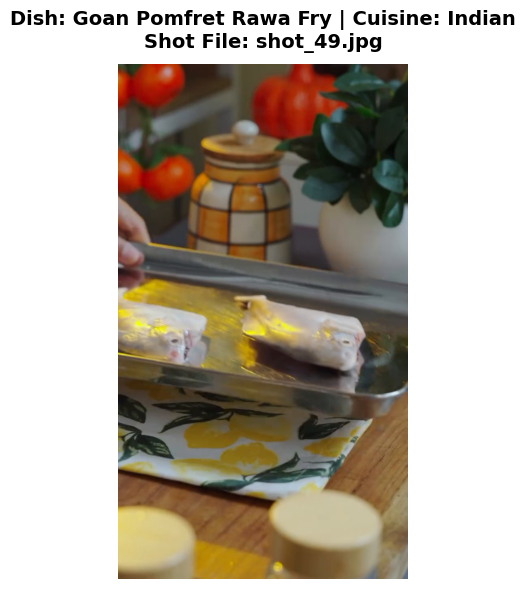

In [61]:
import os
import glob
import json
import matplotlib.pyplot as plt
from PIL import Image

# Directories for Video-RAG project
BASE_DIR = "/kaggle/working/Video-RAG"
KEYFRAMES_DIR = os.path.join(BASE_DIR, "Keyframes")
METADATA_DIR = os.path.join(BASE_DIR, "Metadata")

# Check if Keyframes directory exists
if not os.path.exists(KEYFRAMES_DIR):
    raise FileNotFoundError(f"Keyframes folder not found at '{KEYFRAMES_DIR}'.")

# 1. Discover all dish subdirectories inside Keyframes/
dish_folders = [
    d for d in os.listdir(KEYFRAMES_DIR)
    if os.path.isdir(os.path.join(KEYFRAMES_DIR, d))
]

if not dish_folders:
    print(f"No dish folders found inside '{KEYFRAMES_DIR}'.")
else:
    # Sort dish folders alphabetically for clean output
    dish_folders = sorted(dish_folders)

    # --- STEP 1: Select Dish ---
    print("=== Step 1: Select a Dish ===")
    for idx, dish_name in enumerate(dish_folders, start=1):
        dish_path = os.path.join(KEYFRAMES_DIR, dish_name)
        
        # Count images in this dish folder
        image_files = glob.glob(os.path.join(dish_path, "*.[jJ][pP][gG]")) + \
                      glob.glob(os.path.join(dish_path, "*.[pP][nN][gG]"))
        print(f"[{idx}] {dish_name} ({len(image_files)} keyframe shots)")

    print("\n------------------------------------------------")
    dish_choice = input("Enter the number of the dish you want to view: ").strip()

    if dish_choice.isdigit() and 1 <= int(dish_choice) <= len(dish_folders):
        selected_dish = dish_folders[int(dish_choice) - 1]
        dish_dir_path = os.path.join(KEYFRAMES_DIR, selected_dish)

        # Get and sort shot keyframe images inside the chosen dish folder
        shot_files = sorted(
            glob.glob(os.path.join(dish_dir_path, "*.[jJ][pP][gG]")) + \
            glob.glob(os.path.join(dish_dir_path, "*.[pP][nN][gG]"))
        )

        if not shot_files:
            print(f"No keyframe shots found inside directory: '{dish_dir_path}'")
        else:
            # --- STEP 2: Select Shot inside Chosen Dish ---
            print(f"\n=== Step 2: Select a Shot for [{selected_dish}] ===")
            for s_idx, img_path in enumerate(shot_files, start=1):
                filename = os.path.basename(img_path)
                print(f"  [{s_idx}] {filename}")

            print("\n------------------------------------------------")
            shot_choice = input(f"Enter the shot number for '{selected_dish}': ").strip()

            if shot_choice.isdigit() and 1 <= int(shot_choice) <= len(shot_files):
                selected_image_path = shot_files[int(shot_choice) - 1]
                shot_filename = os.path.basename(selected_image_path)

                # Optional: Fetch metadata details if a JSON exists for this dish
                metadata_info = ""
                meta_matches = glob.glob(os.path.join(METADATA_DIR, f"*{selected_dish}*.json"))
                if meta_matches:
                    try:
                        with open(meta_matches[0], "r", encoding="utf-8") as f:
                            mdata = json.load(f)
                            cuisine = mdata.get("recipe_information", {}).get("cuisine", "")
                            if cuisine:
                                metadata_info = f" | Cuisine: {cuisine}"
                    except Exception:
                        pass

                # --- STEP 3: Display Keyframe Image ---
                img = Image.open(selected_image_path)

                plt.figure(figsize=(10, 6))
                plt.imshow(img)
                plt.axis("off")
                plt.title(
                    f"Dish: {selected_dish}{metadata_info}\nShot File: {shot_filename}",
                    fontsize=14, fontweight="bold", pad=12
                )
                plt.tight_layout()
                plt.show()
            else:
                print(f"[ERROR] Invalid shot choice '{shot_choice}'.")
    else:
        print(f"[ERROR] Invalid dish selection '{dish_choice}'.")

=== Step 1: Select a Dish ===
[1] Caramel Custard (78 keyframe shots)
[2] Coconut Rice (44 keyframe shots)
[3] Goan Pomfret Rawa Fry (100 keyframe shots)
[4] Hilsa Roe in Tangy Tamarind Broth (45 keyframe shots)
[5] Yogurt Chicken (114 keyframe shots)

------------------------------------------------


Enter the number of the dish you want to view:  3



=== Step 2: Select a Shot for [Goan Pomfret Rawa Fry] ===
  [1] shot_01.jpg
  [2] shot_02.jpg
  [3] shot_03.jpg
  [4] shot_04.jpg
  [5] shot_05.jpg
  [6] shot_06.jpg
  [7] shot_07.jpg
  [8] shot_08.jpg
  [9] shot_09.jpg
  [10] shot_10.jpg
  [11] shot_100.jpg
  [12] shot_11.jpg
  [13] shot_12.jpg
  [14] shot_13.jpg
  [15] shot_14.jpg
  [16] shot_15.jpg
  [17] shot_16.jpg
  [18] shot_17.jpg
  [19] shot_18.jpg
  [20] shot_19.jpg
  [21] shot_20.jpg
  [22] shot_21.jpg
  [23] shot_22.jpg
  [24] shot_23.jpg
  [25] shot_24.jpg
  [26] shot_25.jpg
  [27] shot_26.jpg
  [28] shot_27.jpg
  [29] shot_28.jpg
  [30] shot_29.jpg
  [31] shot_30.jpg
  [32] shot_31.jpg
  [33] shot_32.jpg
  [34] shot_33.jpg
  [35] shot_34.jpg
  [36] shot_35.jpg
  [37] shot_36.jpg
  [38] shot_37.jpg
  [39] shot_38.jpg
  [40] shot_39.jpg
  [41] shot_40.jpg
  [42] shot_41.jpg
  [43] shot_42.jpg
  [44] shot_43.jpg
  [45] shot_44.jpg
  [46] shot_45.jpg
  [47] shot_46.jpg
  [48] shot_47.jpg
  [49] shot_48.jpg
  [50] shot_49.jpg

Enter the shot number for 'Goan Pomfret Rawa Fry':  1



[DEBUG] Loading metadata from: Goan Pomfret Rawa Fry_metadata.json

 SHOT INSPECTOR METADATA: Goan Pomfret Rawa Fry
• File Name:     shot_01.jpg
• Shot ID:       shot_01
• Timestamp:     0.0s - 1.33s (Duration: 1.33s)
• Visual VLM:    Keyframe contains: bowl, dining table.
• Recipe Step:   Keyframe contains: bowl, dining table.



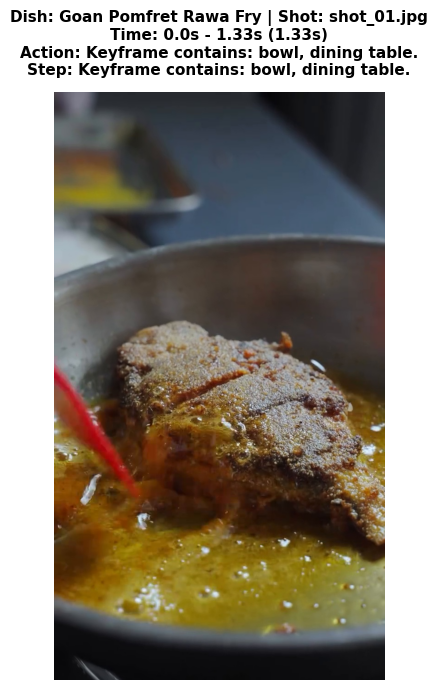

In [19]:
import glob
import json
import os
import re
import matplotlib.pyplot as plt
from PIL import Image

# Directories for Video-RAG project
BASE_DIR = "/kaggle/working/Video-RAG"
KEYFRAMES_DIR = os.path.join(BASE_DIR, "Keyframes")
METADATA_DIR = os.path.join(BASE_DIR, "Metadata")

# Check if Keyframes directory exists
if not os.path.exists(KEYFRAMES_DIR):
    raise FileNotFoundError(f"Keyframes folder not found at '{KEYFRAMES_DIR}'.")

# 1. Discover all dish subdirectories inside Keyframes/
dish_folders = [
    d
    for d in os.listdir(KEYFRAMES_DIR)
    if os.path.isdir(os.path.join(KEYFRAMES_DIR, d))
]

if not dish_folders:
    print(f"No dish folders found inside '{KEYFRAMES_DIR}'.")
else:
    # Sort dish folders alphabetically for clean output
    dish_folders = sorted(dish_folders)

    # --- STEP 1: Select Dish ---
    print("=== Step 1: Select a Dish ===")
    for idx, dish_name in enumerate(dish_folders, start=1):
        dish_path = os.path.join(KEYFRAMES_DIR, dish_name)

        # Count images in this dish folder
        image_files = glob.glob(
            os.path.join(dish_path, "*.[jJ][pP][gG]")
        ) + glob.glob(os.path.join(dish_path, "*.[pP][nN][gG]"))
        print(f"[{idx}] {dish_name} ({len(image_files)} keyframe shots)")

    print("\n------------------------------------------------")
    dish_choice = input(
        "Enter the number of the dish you want to view: "
    ).strip()

    if dish_choice.isdigit() and 1 <= int(dish_choice) <= len(dish_folders):
        selected_dish = dish_folders[int(dish_choice) - 1]
        dish_dir_path = os.path.join(KEYFRAMES_DIR, selected_dish)

        # Get and sort shot keyframe images inside the chosen dish folder
        shot_files = sorted(
            glob.glob(os.path.join(dish_dir_path, "*.[jJ][pP][gG]"))
            + glob.glob(os.path.join(dish_dir_path, "*.[pP][nN][gG]"))
        )

        if not shot_files:
            print(
                f"No keyframe shots found inside directory: '{dish_dir_path}'"
            )
        else:
            # --- STEP 2: Select Shot inside Chosen Dish ---
            print(f"\n=== Step 2: Select a Shot for [{selected_dish}] ===")
            for s_idx, img_path in enumerate(shot_files, start=1):
                filename = os.path.basename(img_path)
                print(f"  [{s_idx}] {filename}")

            print("\n------------------------------------------------")
            shot_choice = input(
                f"Enter the shot number for '{selected_dish}': "
            ).strip()

            if (
                shot_choice.isdigit()
                and 1 <= int(shot_choice) <= len(shot_files)
            ):
                selected_image_path = shot_files[int(shot_choice) - 1]
                shot_filename = os.path.basename(selected_image_path)

                # --- STEP 3: Load Metadata Details ---
                mdata = {}
                meta_matches = glob.glob(
                    os.path.join(METADATA_DIR, f"*{selected_dish}*.json")
                )
                
                # Sort or print matches to ensure the correct JSON is loaded
                if meta_matches:
                    meta_matches = sorted(meta_matches)  # Sorting ensures predictable file selection
                    print(f"\n[DEBUG] Loading metadata from: {os.path.basename(meta_matches[0])}")
                    try:
                        with open(
                            meta_matches[0], "r", encoding="utf-8"
                        ) as f:
                            mdata = json.load(f)
                    except Exception as e:
                        print(f"[WARNING] Could not read JSON metadata: {e}")

                # Extract Shot Index Number from filename (e.g., "shot_01.jpg" -> 1)
                shot_num_match = re.search(r"shot_(\d+)", shot_filename)
                target_shot_id = f"shot_{int(shot_num_match.group(1)):02d}" if shot_num_match else None

                # Extract Shot Timing Info
                start_time = end_time = duration = "N/A"
                if target_shot_id and "shot_information" in mdata:
                    for s in mdata["shot_information"]:
                        if s.get("shot_id") == target_shot_id:
                            start_time = s.get("start_time", "N/A")
                            end_time = s.get("end_time", "N/A")
                            duration = s.get("duration", "N/A")
                            break

                # Extract Visual Description matching target_shot_id
                visual_desc = "N/A"
                if target_shot_id and "visual_descriptions" in mdata:
                    for v in mdata["visual_descriptions"]:
                        if v.get("shot_id") == target_shot_id:
                            visual_desc = v.get("description", "N/A")
                            break

                # Assign directly to recipe_step as requested
                recipe_step = visual_desc

                # Print Detailed Inspector Info to Terminal
                print("\n================================================")
                print(f" SHOT INSPECTOR METADATA: {selected_dish}")
                print("================================================")
                print(f"• File Name:     {shot_filename}")
                print(f"• Shot ID:       {target_shot_id if target_shot_id else 'N/A'}")
                print(f"• Timestamp:     {start_time}s - {end_time}s (Duration: {duration}s)")
                print(f"• Visual VLM:    {visual_desc}")
                print(f"• Recipe Step:   {recipe_step}")
                print("================================================\n")

                # --- STEP 4: Display Image with Shot Details ---
                img = Image.open(selected_image_path)

                plt.figure(figsize=(10, 7))
                plt.imshow(img)
                plt.axis("off")

                # Enhanced Plot Title with Visual Info & Recipe Steps
                title_text = (
                    f"Dish: {selected_dish} | Shot: {shot_filename}\n"
                    f"Time: {start_time}s - {end_time}s ({duration}s)\n"
                    f"Action: {visual_desc}\n"
                    f"Step: {recipe_step}"
                )

                plt.title(
                    title_text,
                    fontsize=11,
                    fontweight="bold",
                    pad=12,
                    loc="center",
                )
                plt.tight_layout()
                plt.show()

            else:
                print(f"[ERROR] Invalid shot choice '{shot_choice}'.")
    else:
        print(f"[ERROR] Invalid dish selection '{dish_choice}'.")

### Video Metadata JSON Viewer

* **File Discovery & Label Mapping:**
  * Scans `/kaggle/working/Video-RAG/Metadata` for generated JSON metadata files via `glob.glob()`.
  * Safely parses each JSON artifact to extract top-level metadata descriptors (`video_info.title` or `recipe_information.dish_type`), dynamically mapping filenames to human-readable display labels with a fallback to raw file names.
* **Interactive Menu & Selection:**
  * Generates an indexed numeric menu of all discovered metadata files alongside their corresponding filenames and video titles.
  * Captures interactive user input to select a target recipe file with built-in numerical validation and error handling.
* **Multi-Lingual Serialization & Formatting:**
  * Loads and pretty-prints the complete JSON hierarchy using `json.dumps(..., indent=2)`.
  * Enforces `ensure_ascii=False` to preserve non-ASCII characters, ensuring native rendering and legibility for multilingual transcriptions (e.g., Bengali script) and localized recipe fields.

In [62]:
import os
import json
import glob

# Path where Step 1 and Step 2 saved the metadata JSONs
METADATA_DIR = "/kaggle/working/Video-RAG/Metadata"

# Find all JSON files in the directory
json_files = glob.glob(os.path.join(METADATA_DIR, "*.json"))

if not json_files:
    print(f"No metadata files found in '{METADATA_DIR}'. Run Steps 1 & 2 first.")
else:
    # 1. Map files to friendly display names (using video title or dish type if available)
    file_options = {}
    
    print("=== Available Recipe Metadata Files ===")
    for idx, json_path in enumerate(json_files, start=1):
        filename = os.path.basename(json_path)
        
        # Read the title or dish name for a user-friendly label
        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                video_title = data.get("video_info", {}).get("title", "")
                dish_type = data.get("recipe_information", {}).get("dish_type", "")
                display_label = video_title or dish_type or filename
        except Exception:
            display_label = filename
            
        file_options[str(idx)] = (json_path, display_label)
        print(f"[{idx}] {display_label} ({filename})")

    # 2. Ask user to choose which metadata to fetch
    print("\n------------------------------------------------")
    user_choice = input("Enter the number of the recipe metadata you want to fetch: ").strip()

    # 3. Retrieve and display the chosen metadata JSON
    if user_choice in file_options:
        selected_path, selected_name = file_options[user_choice]
        print(f"\n=== Displaying Metadata for: {selected_name} ===\n")
        
        with open(selected_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        # Formats and prints the JSON cleanly with proper indentations and Bengali script support
        print(json.dumps(data, indent=2, ensure_ascii=False))
    else:
        print(f"[ERROR] Invalid selection '{user_choice}'. Please choose a valid number from the list.")

=== Available Recipe Metadata Files ===
[1] Hilsa Roe In Tangy Tamarind Broth (Hilsa Roe in Tangy Tamarind Broth_metadata.json)
[2] Caramel Custard (Caramel Custard_metadata.json)
[3] Goan Pomfret Rawa Fry (Goan Pomfret Rawa Fry_metadata.json)
[4] Yogurt Chicken (Yogurt Chicken_metadata.json)
[5] Coconut Rice (Coconut Rice_metadata.json)

------------------------------------------------


Enter the number of the recipe metadata you want to fetch:  3



=== Displaying Metadata for: Goan Pomfret Rawa Fry ===

{
  "video_info": {
    "video_id": "Goan Pomfret Rawa Fry",
    "video_name": "Goan Pomfret Rawa Fry.mp4",
    "title": "Goan Pomfret Rawa Fry",
    "category": "Cooking",
    "language": "bn",
    "duration": 136.58,
    "fps": 24.0,
    "width": 720,
    "height": 1280,
    "total_frames": 3278,
    "file_size": "25.67 MB",
    "video_path": "/kaggle/input/datasets/shibashismandal001/doi-chicken/Goan Pomfret Rawa Fry.mp4"
  },
  "recipe_information": {
    "dish_type": "Fry",
    "ingredients": {
      "fish": [
        "pomfrets"
      ],
      "spices": [
        "Kashmiri dried red chillies",
        "garlic cloves",
        "ginger",
        "cumin seeds",
        "jaggery",
        "turmeric powder"
      ],
      "cooking_fats": [
        "coconut oil"
      ]
    },
    "estimated_steps": [
      "Make 3-4 deep slits on both sides of the pomfret.",
      "Rub with salt, turmeric and lemon and keep aside for 10-15 minute